In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import re
import cv2
import math
import pickle
import random
import time
import warnings
from collections import defaultdict, deque
from datetime import datetime

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import seaborn as sns
from scipy.io import loadmat
from scipy.sparse import csr_matrix
from scipy.stats import norm, expon, lognorm, vonmises
from tqdm import tqdm

In [ ]:
def timer(func):
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        end = time.time()
        print(f"Time taken by func \"{func.__name__}\" : {round(end - start, 6)} seconds")
        return result
    return wrapper

In [ ]:
%cd /content/drive/MyDrive/vis

/content/drive/.shortcut-targets-by-id/1x0X9JLucQlOjpwr70P2e3BcR7ouEShX9/vis


In [ ]:
# !sudo apt-get install tree
%pip install networkit
%pip install rich

from rich.console import Console

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 46.2 MB/s eta 0:00:00


In [ ]:
# # !clear
# !tree 20kX\ Yaxing
# !tree Results\ Yaxing

# (Current Version of code)

## Load

In [ ]:
# # Set the data path
# data_path = '20kX Yaxing'

# sets = ['A', 'B', 'C', 'D']

# image_mapping = {
#     'A': '2045',
#     'B': '1821',
#     'C': '2447',
#     'D': '1750'
# }

# # Load network data
# network_file = os.path.join(data_path, 'sparse_matrices_20kX_new.npz')
# network_data = np.load(network_file, allow_pickle=True)

# # for set_name in sets:
# set_name = 'B'
# edges = network_data[set_name].item()
# rows, cols = edges.nonzero()

# # Automatically generate the file names based on the set name
# positions_file = os.path.join(data_path, f'{set_name}_20kX_postion.npy')
# image_file = os.path.join(data_path, f'300kV 20kX  Pre-GIF {image_mapping[set_name]}.tif')

# # Load node positions_of_nodes
# positions_of_nodes = np.load(positions_file, allow_pickle=True)
# positions_of_nodes[:, [0, 1]] = positions_of_nodes[:, [1, 0]]  # Swap columns to fit the plotting needs

# # Get min and max coordinates for normalization
# min_x = positions_of_nodes[:, 0].min()
# max_x = positions_of_nodes[:, 0].max()
# min_y = positions_of_nodes[:, 1].min()
# max_y = positions_of_nodes[:, 1].max()

# # Normalize and scale positions_of_nodes
# def normalize(value, min_value, max_value):
#     return (value - min_value) / (max_value - min_value)

# # Load and resize original_image
# raw_src = cv2.imread(image_file, cv2.IMREAD_GRAYSCALE)

# h, w = raw_src.shape
# scalefactor = 512 / max(w, h)
# swidth = int(scalefactor * w)
# sheight = int(scalefactor * h)
# dsize = (swidth, sheight)
# canvas_image_gray = cv2.resize(raw_src, dsize)

# canvas_height, canvas_width = canvas_image_gray.shape

# # Normalize and scale positions_of_nodes
# scaled_positions = np.zeros_like(positions_of_nodes)
# scaled_positions[:, 0] = normalize(positions_of_nodes[:, 0], min_x, max_x) * canvas_width
# scaled_positions[:, 1] = normalize(positions_of_nodes[:, 1], min_y, max_y) * canvas_height

# # Convert positions_of_nodes to a dictionary for easier access
# position_dict = {i: pos for i, pos in enumerate(scaled_positions)}

# # Plot original_image and network
# plt.figure(figsize=(10, 10))
# plt.imshow(canvas_image_gray, cmap='gray')

# # Plot edges
# for s, e in zip(rows, cols):
#     if s in position_dict and e in position_dict:
#         x1, y1 = position_dict[s]
#         x2, y2 = position_dict[e]
#         plt.plot([x1, x2], [y1, y2], color='lime', linewidth=2)

# # Plot nodes
# for (x, y) in scaled_positions:
#     plt.plot(x, y, 'bo', markersize=4)

# plt.title(f'Set {set_name}')
# plt.axis('off')
# plt.tight_layout()
# plt.savefig(f'{set_name}.png')
# # plt.show()

In [ ]:
def find_image_file(set_name, resolution, original_graphs_path):
    directory_path = os.path.join(original_graphs_path, set_name)
    if not os.path.exists(directory_path):
        raise FileNotFoundError(f"Directory not found: {directory_path}")

    pattern = re.compile(rf"\b{re.escape(resolution)}\b")
    if (set_name == 'B'):
        directory_path = os.path.join(directory_path, "1811")
    for file_name in os.listdir(directory_path):
        # print(file_name)
        if pattern.search(file_name):
            return os.path.join(directory_path, file_name)

    raise FileNotFoundError(f"No image file found for set {set_name} with resolution {resolution} in {directory_path}")

def load_data(set_name, resolution, base_path='/content/drive/MyDrive/vis'):
    positions_path = os.path.join(base_path, 'position')
    sparse_matrices_path = os.path.join(base_path, 'sparse_matrices')
    original_graphs_path = os.path.join(base_path, 'Original Graphs')

    # Construct file names based on resolution and set name
    positions_file = os.path.join(positions_path, f'{set_name}_{resolution}_postion.npy')
    matrix_file = os.path.join(sparse_matrices_path, f'sparse_matrices_{resolution}.npz')
    # image_file = os.path.join(original_graphs_path, set_name, f'300kV {resolution}  Pre-GIF {get_image_code(set_name, resolution)}.tif')
    image_file = find_image_file(set_name, resolution, original_graphs_path)
    print(f'The position file is {positions_file}, the matrix_file is {matrix_file}, and the image is {image_file}')

    if not os.path.exists(image_file):
        raise FileNotFoundError(f"Image file not found: {image_file}")

    # Load data
    positions = np.load(positions_file, allow_pickle=True)
    if set_name == 'C':
        sparse_matrix = np.load(matrix_file, allow_pickle=True)['C1'].item()
    else:
        sparse_matrix = np.load(matrix_file, allow_pickle=True)[set_name].item()
    image = cv2.imread(image_file, cv2.IMREAD_GRAYSCALE)

    if image is None:
        raise ValueError(f"Failed to load image from file: {image_file}")

    return positions, sparse_matrix, image

def normalize(value, min_value, max_value):
    return (value - min_value) / (max_value - min_value)

def plot_network(positions, sparse_matrix, image, set_name, resolution,
                 save=False, base_path='/content/drive/MyDrive/vis/Results Yaxing'):
    positions[:, [0, 1]] = positions[:, [1, 0]]

    min_x = positions[:, 0].min()
    max_x = positions[:, 0].max()
    min_y = positions[:, 1].min()
    max_y = positions[:, 1].max()

    # Load and resize original_image
    h, w = image.shape
    scalefactor = 512 / max(w, h)
    swidth = int(scalefactor * w)
    sheight = int(scalefactor * h)
    dsize = (swidth, sheight)
    canvas_image_gray = cv2.resize(image, dsize)

    canvas_height, canvas_width = canvas_image_gray.shape

    # Normalize and scale positions_of_nodes
    scaled_positions = np.zeros_like(positions)
    scaled_positions[:, 0] = normalize(positions[:, 0], min_x, max_x) * canvas_width
    scaled_positions[:, 1] = normalize(positions[:, 1], min_y, max_y) * canvas_height

    # Convert positions_of_nodes to a dictionary for easier access
    position_dict = {i: pos for i, pos in enumerate(scaled_positions)}
    rows, cols = sparse_matrix.nonzero()

    # Plot original_image and network
    plt.figure(figsize=(10, 10))
    plt.imshow(canvas_image_gray, cmap='gray')

    # Plot edges
    for s, e in zip(rows, cols):
        if s in position_dict and e in position_dict:
            x1, y1 = position_dict[s]
            x2, y2 = position_dict[e]
            plt.plot([x1, x2], [y1, y2], color='lime', linewidth=2)

    # Plot nodes
    for (x, y) in scaled_positions:
        plt.plot(x, y, 'bo', markersize=4)

    plt.title(f'Original Graph - Set {set_name} Res {resolution}')

    plt.axis('off')
    plt.tight_layout()
    if save:
        folder_name = f"Set {set_name} Res {resolution}"
        folder_path = os.path.join(base_path, folder_name)
        os.makedirs(folder_path, exist_ok=True)
        filename = f'Original Graph - Set {set_name} Res {resolution}.png'
        filepath = os.path.join(folder_path, filename)
        plt.savefig(filepath)
    else:
        plt.show()

    return rows, cols, position_dict

The position file is /content/drive/MyDrive/vis/position/D_10kX_postion.npy, the matrix_file is /content/drive/MyDrive/vis/sparse_matrices/sparse_matrices_10kX.npz, and the image is /content/drive/MyDrive/vis/Original Graphs/D/300kV 10kX  Pre-GIF 1753.tif


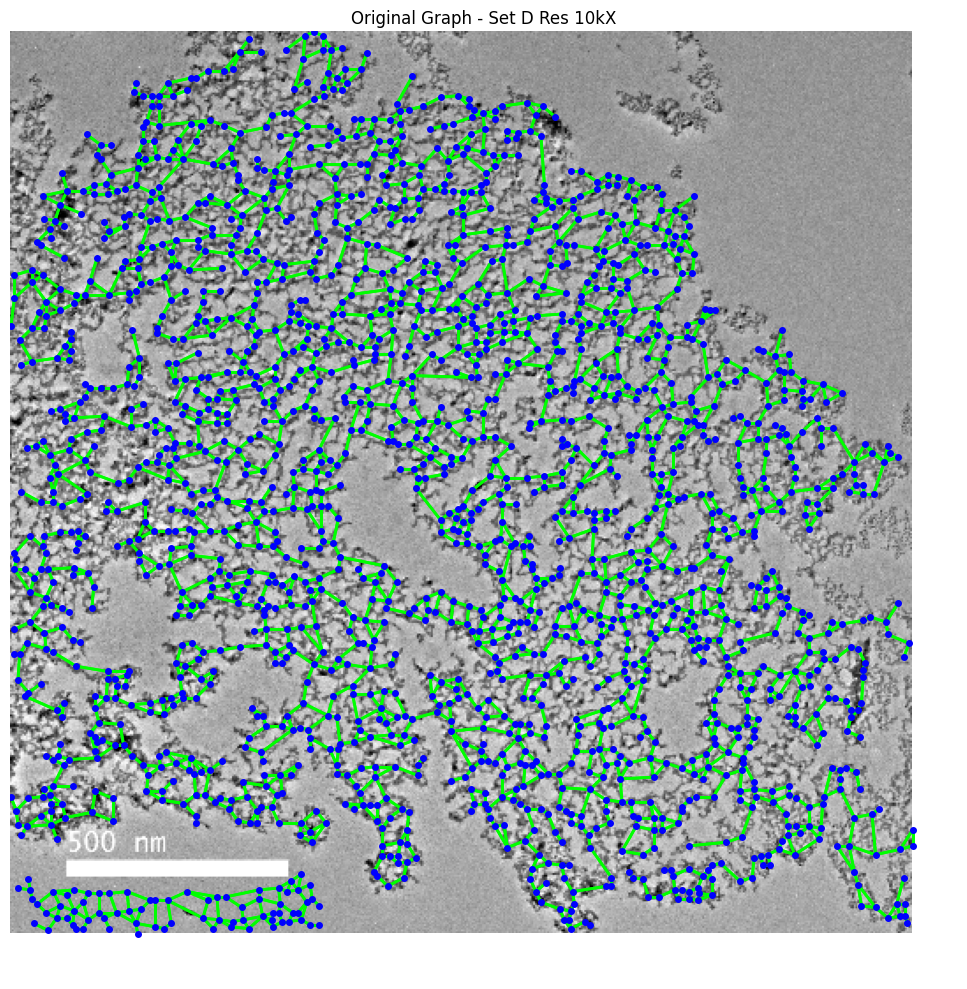

In [ ]:
set_name = 'D'
resolution = '10kX'

positions, sparse_matrix, image = load_data(set_name, resolution)
edges = sparse_matrix
rows, cols, position_dict = plot_network(positions, sparse_matrix, image, set_name, resolution)

## Extract Properties

### Standard Properties of Original Graph

In [ ]:
console = Console()
graph_results = {}

In [ ]:
def print_graph_metrics(graph_metrics, set_name, resolution, mode=1):
    mode_mapping = {
        1: ("blue", f"In Original Graph {set_name} - {resolution}, the distribution is:"),
        2: ("magenta", f"In Mimicked Graph {set_name} - {resolution}, the distribution is:")
    }

    if mode not in mode_mapping:
        raise ValueError("Invalid mode. Available modes: 1 (Original), 2 (Mimicked).")

    color, header = mode_mapping[mode]

    console.print(header, style=f"bold {color}")

    for k in sorted(graph_metrics["degree_distribution"].keys()):
        ratio = round(graph_metrics["degree_distribution"][k], 3)
        console.print(f"- {k}: {ratio}", style=color)

    console.print(f"Mean number of nodes in Graph {set_name} - {resolution}: {graph_metrics['mean_num_nodes']}", style=color)
    console.print(f"Mean number of edges in Graph {set_name} - {resolution}: {graph_metrics['mean_num_edges']}", style=color)
    console.print(f"Average closeness centrality in Graph {set_name} - {resolution}: {graph_metrics['avg_closeness_centrality']}", style=color)
    console.print(f"Average degree in Graph {set_name} - {resolution}: {graph_metrics['avg_degree']}", style=color)

def compute_graph_metrics(set_name, resolution, base_path='/content/drive/MyDrive/vis'):
    cache_key = f"{set_name}_{resolution}"

    if cache_key not in graph_results:
        positions, sparse_matrix, _ = load_data(set_name, resolution, base_path=base_path)

        adj_matrix = np.array(sparse_matrix.toarray())
        G_original = nx.from_numpy_array(adj_matrix)

        degrees_original = dict(G_original.degree())
        unique_degrees_original, counts_original = np.unique(list(degrees_original.values()), return_counts=True)
        degree_distribution_original = dict(zip(unique_degrees_original, counts_original / sum(counts_original)))

        mean_num_nodes_original = G_original.number_of_nodes()
        mean_num_edges_original = G_original.number_of_edges()
        avg_degree_original = np.mean(list(degrees_original.values()))

        closeness_centrality_original = nx.closeness_centrality(G_original)
        avg_closeness_centrality_original = np.mean(list(closeness_centrality_original.values()))

        graph_results[cache_key] = {
            "degree_distribution": degree_distribution_original,
            "mean_num_nodes": mean_num_nodes_original,
            "mean_num_edges": mean_num_edges_original,
            "avg_closeness_centrality": avg_closeness_centrality_original,
            "avg_degree": avg_degree_original
        }

    print_graph_metrics(graph_results[cache_key], set_name, resolution, mode=1)

def print_cached_metrics(set_name, resolution, mode=1):
    cache_key = f"{set_name}_{resolution}"

    if cache_key in graph_results:
        print_graph_metrics(graph_results[cache_key], set_name, resolution, mode)
    else:
        console.print(f"No cached metrics found for paradigm_network {set_name} - {resolution}.", style="bold red")

# compute_graph_metrics('A', '10kX')
# compute_graph_metrics('B', '20kX')
# compute_graph_metrics('C', '30kX')
compute_graph_metrics('D', '10kX')

The position file is /content/drive/MyDrive/vis/position/D_10kX_postion.npy, the matrix_file is /content/drive/MyDrive/vis/sparse_matrices/sparse_matrices_10kX.npz, and the image is /content/drive/MyDrive/vis/Original Graphs/D/300kV 10kX  Pre-GIF 1753.tif


In Original Graph D - 10kX, the distribution is:

- 1: 0.068

- 2: 0.306

- 3: 0.513

...

- 6: 0.003

Mean number of nodes in Graph D - 10kX: 1949

Mean number of edges in Graph D - 10kX: 2621

Average closeness centrality in Graph D - 10kX: 0.0241662261420542

Average degree in Graph D - 10kX: 2.689584402257568

### Propobilities Distribution

In [ ]:
def calculate_distance(p1, p2):
    return np.linalg.norm(np.array(p1) - np.array(p2))

In [ ]:
def propobilities_distribution(rows, cols, position_dict):
    # In Degree
    in_degree_count = defaultdict(int)
    for start, end in zip(rows, cols):
        in_degree_count[start] += 1
    in_degree_count = {node: degree for node, degree in in_degree_count.items() if degree > 0}

    # Group nodes by degree
    nodes_by_degree = defaultdict(list)
    for node, degree in in_degree_count.items():
        nodes_by_degree[degree].append(node)

    # Calculate degree probabilities
    total_nodes = len(in_degree_count)
    degree_probabilities = {degree: len(nodes) / total_nodes for degree, nodes in nodes_by_degree.items()}

    # Adjacency Dictionary
    adjacency_dict = defaultdict(set)
    for start, end in zip(rows, cols):
        adjacency_dict[start].add(end)
        adjacency_dict[end].add(start)

    # Mapping from each degree to the degrees of its connected vertices
    degree_neighbors_map = defaultdict(list)
    for node, neighbors in adjacency_dict.items():
        node_degree = in_degree_count[node]
        neighbor_degrees = [in_degree_count[neighbor] for neighbor in neighbors]
        degree_neighbors_map[node_degree].extend(neighbor_degrees)

    # Calculate degree transition probabilities
    degree_transition_probs = {}
    for degree, neighbor_degrees in degree_neighbors_map.items():
        degree_distribution = defaultdict(int)
        for neighbor_degree in neighbor_degrees:
            degree_distribution[neighbor_degree] += 1
        total_neighbors = sum(degree_distribution.values())
        degree_transition_probs[degree] = {k: v / total_neighbors for k, v in degree_distribution.items()}

    # Degree Edge Lengths and Angles Calculation (Existing Code)
    edge_lengths_by_degree = defaultdict(list)
    angles_by_degree = defaultdict(list)

    normalized_positions = {node: np.array(position, dtype=np.float64) for node, position in position_dict.items()}

    total_length_sum = 0
    total_length_count = 0

    for node, node_pos in normalized_positions.items():
        if node not in in_degree_count:
            continue

        neighbors = list(adjacency_dict[node])
        lengths = [calculate_distance(node_pos, normalized_positions[n]) for n in neighbors if n in normalized_positions]
        node_degree = in_degree_count[node]
        if node_degree > 0:
            edge_lengths_by_degree[node_degree].extend(lengths)

        total_length_sum += sum(lengths)
        total_length_count += len(lengths)

        if len(neighbors) > 1:
            # Convert neighbors to polar coordinates (angle relative to the node)
            polar_coords = [(n, np.arctan2(np.float64(normalized_positions[n][1] - node_pos[1]), np.float64(normalized_positions[n][0] - node_pos[0])))
                            for n in neighbors if n in normalized_positions]

            # Sort neighbors by their polar angle
            polar_coords.sort(key=lambda x: x[1])

            # Calculate angles between adjacent edges
            angles = []
            for i in range(len(polar_coords)):
                angle_diff = (polar_coords[(i + 1) % len(polar_coords)][1] - polar_coords[i][1]) * (180 / np.pi)
                if angle_diff < 0:
                    angle_diff += 360
                angles.append(round(angle_diff, 0))

            if node_degree > 0:
                angles_by_degree[node_degree].extend(angles)

    average_length = total_length_sum / total_length_count if total_length_count > 0 else 0
    return adjacency_dict, in_degree_count, degree_transition_probs, angles_by_degree, edge_lengths_by_degree, average_length

In [ ]:
adjacency_dict, in_degree_count, degree_transition_probs, angles_by_degree, edge_lengths_by_degree, average_length = propobilities_distribution(rows, cols, position_dict)

In [ ]:
degree_transition_probs.keys(), angles_by_degree.keys(), edge_lengths_by_degree.keys()

(dict_keys([2, 3, 1, 4, 5, 6]),
 dict_keys([2, 3, 4, 5, 6]),
 dict_keys([2, 3, 1, 4, 5, 6]))

### Map Length to Weight

In [ ]:
def map_length_to_weight(length, length_bins, weight_baskets, y):
    bin_idx = np.digitize(length, length_bins) - 1
    bin_idx = np.clip(bin_idx, 0, len(length_bins) - 2)

    if weight_baskets[bin_idx]:
        return random.choice(weight_baskets[bin_idx])
    else:
        return np.mean(y)

def mapping(position_dict, edges, plot=False):
    edge_lengths = []
    edge_weights = []

    normalized_positions = {node: np.array(position, dtype=np.float64) for node, position in position_dict.items()}

    for node, node_pos in normalized_positions.items():
        if node not in in_degree_count:
            continue

        neighbors = list(adjacency_dict[node])
        for neighbor in neighbors:
            if neighbor in normalized_positions:
                length = calculate_distance(node_pos, normalized_positions[neighbor])
                weight = edges[node, neighbor]

                edge_lengths.append(length)
                edge_weights.append(weight)

    X = np.array(edge_lengths).reshape(-1, 1).flatten()
    y = np.array(edge_weights)

    num_bins = 100
    length_bins = np.linspace(X.min(), X.max(), num_bins + 1)
    weight_baskets = {i: [] for i in range(num_bins)}

    for length, weight in zip(X, y):
        bin_idx = np.digitize(length, length_bins) - 1
        bin_idx = np.clip(bin_idx, 0, num_bins - 1)
        weight_baskets[bin_idx].append(weight)

    def map_length_to_weight(length, length_bins, weight_baskets, y):
        bin_idx = np.digitize(length, length_bins) - 1
        bin_idx = np.clip(bin_idx, 0, len(length_bins) - 2)
        if weight_baskets[bin_idx]:
            return random.choice(weight_baskets[bin_idx])
        else:
            return np.mean(y)

    mapped_weights = [map_length_to_weight(length, length_bins, weight_baskets, y) for length in X]

    if not plot:
        return mapped_weights, map_length_to_weight, length_bins, weight_baskets, y

    plt.figure(figsize=(8, 6))
    plt.scatter(X, y, c='blue', alpha=0.4, label='Original Data')
    plt.scatter(X, mapped_weights, c='orange', alpha=0.6, label='Mapped Weights')
    plt.title('Edge Length vs Weight with Basket-Based Mapping')
    plt.xlabel('Length')
    plt.ylabel('Weight')
    plt.legend()
    plt.grid(False)
    plt.show()

    return mapped_weights, map_length_to_weight, length_bins, weight_baskets, y

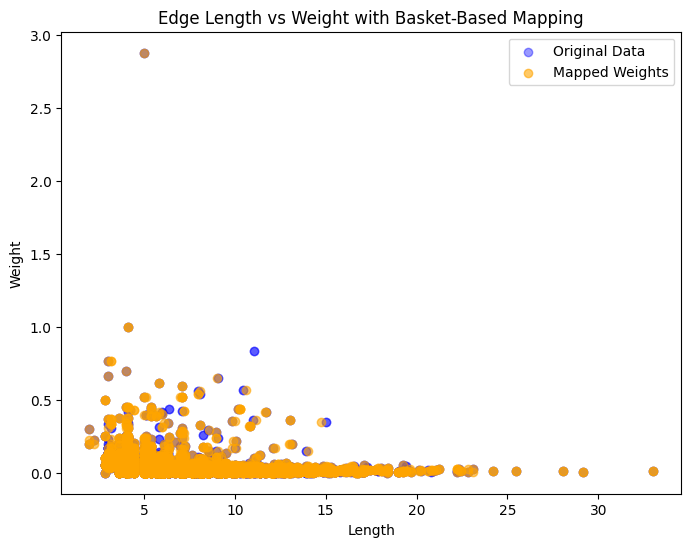

In [ ]:
mapped_weights = mapping(position_dict, edges, plot=True)

## Design Nodes

In [ ]:
class GraphNode:
    degree_distribution = []
    degree_transition_probs = {}
    degree_angles = {}
    degree_edge_lengths = {}
    node_grid = defaultdict(set)
    edge_grid = defaultdict(set)
    grid_size = 13  # The default value is the average value of lengths in the original network
    closed_nodes_factor = 1.2
    closed_edges_factor = 0.8
    aborted_edge = 0
    merged_edge = 0
    id_counter = 0

    enable_check_intersection = True
    enable_merge_nodes = True
    enable_clockwise = True
    enable_degree_transition_probs = True
    enable_merge_edges = True


    def __init__(self, position, *, parent=None, parent_angle=None):
        '''
        PRE: param parent and parent_angle must be provided together or not at all.
        POST: The first children of a non-root node is the parent.
        '''
        self.id = GraphNode.id_counter
        GraphNode.id_counter += 1
        self.position = position
        self.clockwise = random.choice([True, False]) if GraphNode.enable_clockwise else True
        self.parent = parent
        self.children = []

        if parent is not None and parent_angle is not None:  # Non-root Node
            self.degree = self.choose_degree_based_on_parent(parent.degree) if GraphNode.enable_degree_transition_probs else random.choice(GraphNode.degree_distribution)
            self.base_angle = (parent_angle + 180) % 360
            self.add_child(self.parent)
        elif parent is None and parent_angle is None:  # Root Node
            self.degree = random.choice(GraphNode.degree_distribution)
            self.base_angle = random.uniform(0, 360)
            self.initialize_root_node()
        else:
            raise ValueError("Both parent and parent_angle must be provided together or not at all.")

    def choose_degree_based_on_parent(self, parent_degree):
        degrees = list(GraphNode.degree_transition_probs[parent_degree].keys())
        probabilities = list(GraphNode.degree_transition_probs[parent_degree].values())
        return np.random.choice(degrees, p=probabilities)

    def initialize_root_node(self):
        length = random.choice(GraphNode.degree_edge_lengths[self.degree])
        child_position = self.polar_to_cartesian([length], [self.base_angle])[0]
        child = GraphNode(child_position, parent=self, parent_angle=self.base_angle)
        edge = (self.position, child_position)
        self.add_child(child)
        self.add_to_grid(self.position)
        self.add_to_grid(child.position)
        self.add_edge_to_grid(edge)

    def add_child(self, child):
        if len(self.children) >= self.degree:
            raise Exception(f"Node {self} cannot have more than {self.degree} children, current children {self.children}")
        self.children.append(child)
        self.add_to_grid(child.position)

    def add_to_grid(self, position):
        key = self.spatial_hash(position)
        GraphNode.node_grid[key].add(self)
        if len(GraphNode.node_grid[key]) > 1000:
            print("Unusual length of nodes collision chain")

    def add_edge_to_grid(self, edge):
        keys = self.edge_spatial_hash(*edge)
        for key in keys:
            GraphNode.edge_grid[key].add(edge)
            if len(GraphNode.edge_grid[key]) > 1000:
                print("Unusual length of edges collision chain")

    def generate_children(self) -> bool:
        if len(self.children) > 1 or self.degree == 1: # Skip visited nodes or Endpoint has no other child
            return False
        angles, lengths = self.generate_angles_and_lengths()
        children_positions = self.polar_to_cartesian(lengths, angles)
        assert len(children_positions) == self.degree - 1

        for child_position, angle in zip(children_positions, angles):
            if GraphNode.enable_merge_edges and self.find_close_edge(child_position):
                GraphNode.aborted_edge += 1
                continue
            close_node = self.get_closest_valid_node(child_position)
            new_edge = (self.position, child_position)
            if GraphNode.enable_merge_nodes and close_node is not None:
                new_edge = (self.position, close_node.position)
                if not self.check_intersection(new_edge):
                    self.add_child(close_node)
                    self.add_edge_to_grid(new_edge)
                    GraphNode.merged_edge += 1
                else:
                    GraphNode.aborted_edge += 1
            else:
                if not self.check_intersection(new_edge):
                    child_node = GraphNode(child_position, parent=self, parent_angle=angle)
                    self.add_child(child_node)
                    self.add_edge_to_grid(new_edge)
                    self.add_to_grid(child_node.position)
                else:
                    GraphNode.aborted_edge += 1
        return True

    def get_closest_valid_node(self, position):
        close_nodes_with_distances = self.find_close_node(position)
        if close_nodes_with_distances:
            return min(close_nodes_with_distances, key=lambda x: x[1])[0]
        return None

    def find_close_node(self, position):
        threshold = GraphNode.grid_size * GraphNode.closed_nodes_factor
        key = self.spatial_hash(position)
        neighboring_keys = [
            (key[0] + dx, key[1] + dy)
            for dx in range(-1, 2)
            for dy in range(-1, 2)
        ]
        close_nodes_with_distances = []
        for neighbor_key in neighboring_keys:
            for node in GraphNode.node_grid[neighbor_key]:
                if node != self and node not in self.children:
                    distance = np.linalg.norm(np.array(node.position) - np.array(position))
                    if distance < threshold:
                        close_nodes_with_distances.append((node, distance))
        return close_nodes_with_distances

    def generate_angles_and_lengths(self):
        if self.degree == 1:
            return [], []
        angles = random.choices(GraphNode.degree_angles[self.degree], k=self.degree-1)
        angles = np.cumsum(angles) if self.clockwise else np.cumsum([-angle for angle in angles])
        angles = (angles + self.base_angle).tolist()
        lengths = random.choices(GraphNode.degree_edge_lengths[self.degree], k=self.degree-1)
        return angles, lengths

    def polar_to_cartesian(self, lengths, angles):
        x, y = self.position
        cartesian_coords = []
        for length, angle in zip(lengths, angles):
            angle_rad = np.deg2rad(angle)
            new_x = x + length * np.cos(angle_rad)
            new_y = y + length * np.sin(angle_rad)
            cartesian_coords.append((new_x, new_y))
        return cartesian_coords

    def find_close_edge(self, position):
        key = self.spatial_hash(position)
        neighboring_keys = [
            (key[0] + dx, key[1] + dy)
            for dx in range(-1, 2)
            for dy in range(-1, 2)
        ]
        for neighbor_key in neighboring_keys:
            for edge in GraphNode.edge_grid[neighbor_key]:
                if self.is_non_sibling_edge(edge, position):
                    return True
        return False

    def is_non_sibling_edge(self, edge, position):
        threshold = GraphNode.grid_size * GraphNode.closed_edges_factor
        if self.parent and (self.parent.position in edge or self.position in edge):
            return False  # Skip edges from the same parent
        p1, p2 = edge
        distances = [
            np.linalg.norm(np.array(position) - np.array(p1)),
            np.linalg.norm(np.array(position) - np.array(p2))
        ]
        return any(distance < threshold for distance in distances)

    def check_intersection(self, new_edge):
        if not GraphNode.enable_check_intersection:
            return False
        keys = self.edge_spatial_hash(*new_edge)
        for key in keys:
            for edge in GraphNode.edge_grid[key]:
                # if new_edge[0] == edge[0] or new_edge[0] == edge[1] or new_edge[1] == edge[0] or new_edge[1] == edge[1]:
                if new_edge[0] in edge or new_edge[1] in edge:
                    continue  # Skip edges with the same endpoint
                if GraphNode.do_intersect(new_edge[0], new_edge[1], edge[0], edge[1]):
                    return True
        return False

    @staticmethod
    def spatial_hash(position, grid_size=None):
        grid_size = grid_size or GraphNode.grid_size
        return (int(position[0] // grid_size), int(position[1] // grid_size))

    @staticmethod
    def edge_spatial_hash(p1, p2, grid_size=None):
        grid_size = grid_size or GraphNode.grid_size
        x_min, x_max = sorted([p1[0], p2[0]])
        y_min, y_max = sorted([p1[1], p2[1]])
        keys = {(int(x // grid_size), int(y // grid_size))
                for x in np.arange(x_min, x_max + grid_size, grid_size)
                for y in np.arange(y_min, y_max + grid_size, grid_size)}
        return keys

    @staticmethod
    def do_intersect(p1, q1, p2, q2):
        def orientation(p, q, r):
            val = (q[1] - p[1]) * (r[0] - q[0]) - (q[0] - p[0]) * (r[1] - q[1])
            return 0 if val == 0 else 1 if val > 0 else 2

        def on_segment(p, q, r):
            return min(p[0], r[0]) <= q[0] <= max(p[0], r[0]) and min(p[1], r[1]) <= q[1] <= max(p[1], r[1])

        o1, o2, o3, o4 = orientation(p1, q1, p2), orientation(p1, q1, q2), orientation(p2, q2, p1), orientation(p2, q2, q1)
        return (o1 != o2 and o3 != o4) or (o1 == 0 and on_segment(p1, p2, q1)) or (o2 == 0 and on_segment(p1, q2, q1)) or (o3 == 0 and on_segment(p2, p1, q2)) or (o4 == 0 and on_segment(p2, q1, q2))

    @staticmethod
    def reset(default_grid_size=13):
        GraphNode.node_grid.clear()
        GraphNode.edge_grid.clear()
        GraphNode.aborted_edge = 0
        GraphNode.merged_edge = 0
        GraphNode.grid_size = default_grid_size
        GraphNode.id_counter = 0

    def __repr__(self):
        return f"Node (Id. {self.id})"

    def __str__(self):
        return f"Node (Id. {self.id})"

    # Since we use the coordinates of nodes to deal with hashing, no need to overwrite __eq__ and __hash__
def reset_graph_node(grid_size=13, **kwargs):
    GraphNode.reset(grid_size)
    for attr, value in kwargs.items():
        if hasattr(GraphNode, attr):
            setattr(GraphNode, attr, value)

GraphNode.degree_distribution = list(in_degree_count.values())
GraphNode.degree_transition_probs = degree_transition_probs
GraphNode.degree_angles = angles_by_degree
GraphNode.degree_edge_lengths = edge_lengths_by_degree

## Generate Graph

In [ ]:
@timer
def generate_nodes_and_edges(frame_boundaries=[[-1000, 1000], [-1000, 1000]], grid_size=13, **kwargs):
    # Reset GraphNode with provided settings
    reset_graph_node(grid_size=grid_size, **kwargs)

    root_node = GraphNode((0, 0))
    node_set = {root_node}
    edge_set = set()

    def is_position_within_frame(position, frame):
        x, y = position
        return frame[0][0] <= x <= frame[0][1] and frame[1][0] <= y <= frame[1][1]

    def bfs(root, frame):
        node_queue = deque([root])
        while node_queue:
            if len(node_set) >= 1e5:
                print(f"Excessive node count detected: {len(node_set)}. Aborting...")
                break

            current_node = node_queue.popleft()
            if not is_position_within_frame(current_node.position, frame):
                continue

            if current_node.generate_children():
                for child in current_node.children:
                    if child == current_node:
                        continue  # Skip the parent node
                    node_set.add(child)
                    edge_set.add((current_node.position, child.position))
                    node_queue.append(child)  # Warning: Potential infinite loop due to merging

    bfs(root_node, frame_boundaries)
    return node_set, edge_set


def plot_and_generate_network(node_set=None, edge_set=None, frame_range=500, regenerate=False, skip_plotting=False, node_only=False, save_plot=False, **kwargs):
    if node_set is None:
        node_set = []
    if edge_set is None:
        edge_set = []

    frame_boundaries = [[-frame_range, frame_range], [-frame_range, frame_range]]
    regen_factor = kwargs.get('regen_factor', 1)
    graph_title = kwargs.get('graph_title', "")
    if regenerate:
        while len(node_set) <= 100:
            all_edge_lengths = [length for lengths in GraphNode.degree_edge_lengths.values() for length in lengths]
            mean_edge_length = np.mean(all_edge_lengths)
            node_set, edge_set = generate_nodes_and_edges(
                frame_boundaries=frame_boundaries,
                grid_size=int(round(regen_factor * mean_edge_length, 0)),
                **kwargs
            )
            if len(node_set) > 100:
                print(f"Nodes generated: {len(node_set)}, edges: {len(edge_set)}.\tAborted edges: {GraphNode.aborted_edge}, merged edges: {GraphNode.merged_edge}")

    if node_only:
        return node_set, edge_set, None, None, None

    x_positions = [node.position[0] for node in node_set]
    y_positions = [node.position[1] for node in node_set]

    center_x = sum(x_positions) / len(x_positions)
    center_y = sum(y_positions) / len(y_positions)

    def create_adjacency_matrix(nodes, edges):
        node_position_map = {node.position: idx for idx, node in enumerate(nodes)}
        adjacency_matrix = np.zeros((len(nodes), len(nodes)), dtype=int)

        for edge in edges:
            idx1 = node_position_map[edge[0]]
            idx2 = node_position_map[edge[1]]
            adjacency_matrix[idx1, idx2] = adjacency_matrix[idx2, idx1] = 1

        return adjacency_matrix

    # Determine nodes and edges within the frame
    filtered_nodes = {node for node in node_set
                      if center_x - frame_range / 2 <= node.position[0] <= center_x + frame_range / 2 and
                      center_y - frame_range / 2 <= node.position[1] <= center_y + frame_range / 2}
    filtered_edges = {edge for edge in edge_set
                      if center_x - frame_range / 2 <= edge[0][0] <= center_x + frame_range / 2 and
                      center_y - frame_range / 2 <= edge[0][1] <= center_y + frame_range / 2 and
                      center_x - frame_range / 2 <= edge[1][0] <= center_x + frame_range / 2 and
                      center_y - frame_range / 2 <= edge[1][1] <= center_y + frame_range / 2}
    adjacency_matrix = create_adjacency_matrix(filtered_nodes, filtered_edges)

    if skip_plotting:
        print(f"Nodes after filtering: {len(filtered_nodes)}, edges after filtering: {len(filtered_edges)}")
        return node_set, edge_set, filtered_nodes, filtered_edges, adjacency_matrix

    # Plot original_image and network
    fig, ax = plt.subplots(figsize=(10, 10))

    ax.set_xlim(center_x - frame_range / 2, center_x + frame_range / 2)
    ax.set_ylim(center_y - frame_range / 2, center_y + frame_range / 2)

    for edge in edge_set:
        ax.plot([edge[0][0], edge[1][0]], [edge[0][1], edge[1][1]], 'b-', linewidth=0.5, zorder=2)

    for node in node_set:
        ax.plot(node.position[0], node.position[1], 'ro', markersize=1.5, zorder=2)

    scale_length = 100
    scale_x_start = center_x - frame_range / 2 + 50
    scale_y = center_y - frame_range / 2 + 50

    background_rect = plt.Rectangle((scale_x_start - 5, scale_y - 10), scale_length + 10, 20, facecolor='white', edgecolor='none', zorder=3)
    ax.add_patch(background_rect)
    ax.plot([scale_x_start, scale_x_start + scale_length], [scale_y, scale_y], 'k-', linewidth=2, zorder=3)
    ax.text(scale_x_start + scale_length / 2, scale_y + 5, f'{scale_length}', ha='center', fontsize=12, color='black', zorder=4)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

    plt.title('Generated Graph Based on Probability Distributions')
    if save_plot:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f'{graph_title}_graph_{timestamp}.png'
        plt.savefig('Results Yaxing' + filename, dpi=600)
        print(f"Graph saved as {filename}")
    else:
        plt.show()

    print(f"Nodes after filtering: {len(filtered_nodes)}, edges after filtering: {len(filtered_edges)}")
    return node_set, edge_set, filtered_nodes, filtered_edges, adjacency_matrix

Time taken by func "generate_nodes_and_edges" : 15.340454 seconds
Nodes generated: 9993, edges: 23317.	Aborted edges: 5889, merged edges: 3760


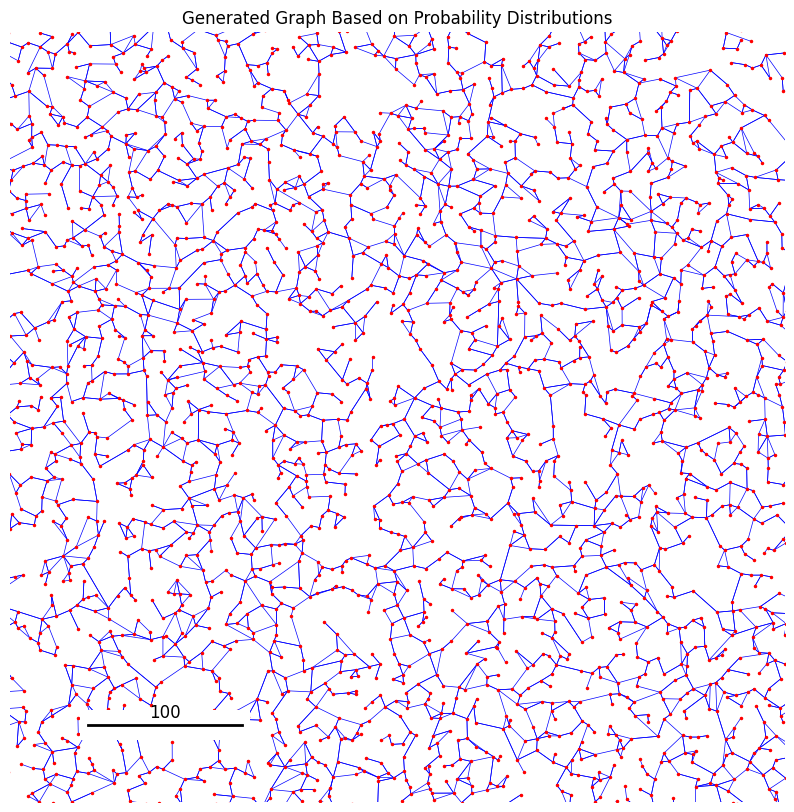

Nodes after filtering: 2525, edges after filtering: 5818


In [ ]:
_, _, filtered_nodes, filtered_edges, adjacency_matrix = plot_and_generate_network(node_set=None, edge_set=None, frame_range=500, regenerate=True)

## Filter the graph

In [ ]:
# Constants
NUM_NODES_ORIGINAL = 845
NUM_EDGES_ORIGINAL = 1107
AVERAGE_DEGREE_ORIGINAL = 2 * NUM_EDGES_ORIGINAL / NUM_NODES_ORIGINAL

@timer
def iteratively_reduce_degree(adj_matrix, target_avg_degree, min_component_size=10):
    G = nx.from_numpy_array(adj_matrix)

    while True:
        # Remove small connected components
        components = list(nx.connected_components(G))
        for component in components:
            if len(component) < min_component_size:
                G.remove_nodes_from(component)

        degrees = dict(G.degree())
        avg_degree = np.mean(list(degrees.values()))

        if avg_degree <= target_avg_degree:
            break

        # Find the node with the highest degree and remove
        max_degree_node = max(degrees, key=degrees.get)
        G.remove_node(max_degree_node)

        # Remove nodes with degree 0 (standalone nodes)
        nodes_to_remove = [node for node, degree in G.degree() if degree == 0]
        G.remove_nodes_from(nodes_to_remove)

    new_adj_matrix = nx.to_numpy_array(G)
    return G, new_adj_matrix

def plot_reduced_graph(G_reduced, val_nodes, title, set_name, resolution, save, base_path='/content/drive/MyDrive/vis/Results Yaxing/'):
    plt.figure(figsize=(10, 10))

    positions = {i: (node.position[0], node.position[1]) for i, node in enumerate(val_nodes)}
    filtered_nodes = list(G_reduced.nodes)
    filtered_edges = list(G_reduced.edges)

    for s, e in filtered_edges:
        if s in positions and e in positions:
            x1, y1 = positions[s]
            x2, y2 = positions[e]
            plt.plot([x1, x2], [y1, y2], 'b-', linewidth=.5, zorder=2)

    for node in filtered_nodes:
        if node in positions:
            x, y = positions[node]
            plt.plot(x, y, 'ro', markersize=1.5, zorder=2)

    plt.axis('off')
    # plt.title(title)
    plt.tight_layout()

    if save:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        folder_name = f"Synthetic Graph - Set {set_name} Res {resolution}"
        folder_path = os.path.join(base_path, folder_name)
        os.makedirs(folder_path, exist_ok=True)
        filename = f"Synthetic Graph - Set {set_name} Res {resolution} Time {timestamp}.png"
        filepath = os.path.join(folder_path, filename)
        plt.savefig(filepath)

    plt.show()

    # Calculate crucial original_graph metrics
    degrees = dict(G_reduced.degree())
    unique_degrees, counts = np.unique(list(degrees.values()), return_counts=True)
    degree_distribution = dict(zip(unique_degrees, counts / sum(counts)))

    mean_num_nodes = G_reduced.number_of_nodes()
    mean_num_edges = G_reduced.number_of_edges()
    avg_degree = np.mean(list(degrees.values()))
    closeness_centrality = nx.closeness_centrality(G_reduced)
    avg_closeness_centrality = np.mean(list(closeness_centrality.values()))

    return {
        "degree_distribution": degree_distribution,
        "mean_num_nodes": mean_num_nodes,
        "mean_num_edges": mean_num_edges,
        "avg_closeness_centrality": avg_closeness_centrality,
        "avg_degree": avg_degree
    }

In [ ]:
# _, _, filtered_nodes, filtered_edges, adj_matrix = plot_and_generate_network(skip_plotting=True, regenerate=True, regen_factor=1)
# G_reduced, adj_reduced = iteratively_reduce_degree(adj_matrix, AVERAGE_DEGREE_ORIGINAL)
# graph_metrics = plot_reduced_graph(G_reduced, filtered_nodes, f'Reduced Graph', save=True)
# print_graph_metrics(graph_metrics, set_name, mode=2)  # mode=2 -> "Mimicked"

In [ ]:
# compute_graph_metrics(set_name)

## Analyse the graph generated

In [ ]:
import pickle
from collections import Counter
import math
from scipy import stats
import networkit as nk
from tqdm import tqdm

In [ ]:
def calculate_edge_lengths(nodes, edges):
    edge_lengths = []
    for u, v in edges:
        length = calculate_distance(nodes[u], nodes[v])
        edge_lengths.append(length)
    return edge_lengths

def assign_weights_to_edges(node_dimension, edges, map_length_to_weight, length_bins, weight_baskets, y):
    edge_lengths = calculate_edge_lengths(node_dimension, edges)
    weights = [map_length_to_weight(length, length_bins, weight_baskets, y) for length in edge_lengths]

    G_weighted = nx.Graph()
    for (u, v), weight in zip(edges, weights):
        G_weighted.add_edge(u, v, weight=weight)

    return G_weighted

def reindex_graph_nodes(G):
    mapping = {node: idx for idx, node in enumerate(G.nodes())}
    return nx.relabel_nodes(G, mapping), mapping

def plot_reduced_graph_with_positions(G, node_positions, title, save=False, base_path='/content/drive/MyDrive/vis/Results Yaxing/'):
    plt.figure(figsize=(10, 10))

    for s, e in G.edges:
        x1, y1 = node_positions[s]
        x2, y2 = node_positions[e]
        plt.plot([x1, x2], [y1, y2], 'b-', linewidth=0.5, zorder=2)

    for node in G.nodes:
        x, y = node_positions[node]
        plt.plot(x, y, 'ro', markersize=1.5, zorder=2)

    plt.axis('off')
    title = f"Synthetic Graph - Set {set_name} Res {resolution}"
    plt.title(title)
    plt.tight_layout()

    if save:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        main_folder_name = f"Set {set_name} Res {resolution}"
        synthetic_folder_name = f"Synthetic Graph - Set {set_name} Res {resolution}"
        main_folder_path = os.path.join(base_path, main_folder_name)
        synthetic_folder_path = os.path.join(main_folder_path, synthetic_folder_name)
        os.makedirs(synthetic_folder_path, exist_ok=True)
        filename = f"{title} Set {set_name} Res {resolution} Time {timestamp}.png"
        filepath = os.path.join(synthetic_folder_path, filename)
        plt.savefig(filepath)
    else:
        plt.show()

# _, _, filtered_nodes, filtered_edges, adj_matrix = plot_and_generate_network(skip_plotting=True, regenerate=True, regen_factor=1)
# G_reduced, adj_reduced = iteratively_reduce_degree(adj_matrix, AVERAGE_DEGREE_ORIGINAL)
# filtered_nodes_dict = {i: node.position for i, node in enumerate(filtered_nodes)}
# G_reduced_reindexed, node_mapping = reindex_graph_nodes(G_reduced)
# # original_positions = {node: filtered_nodes_dict[node] for node in G_reduced.nodes()}
# # plot_reduced_graph_with_positions(G_reduced, original_positions, "Reduced Graph")
# reindexed_positions = {node_mapping[node]: filtered_nodes_dict[node] for node in G_reduced.nodes()}
# reindexed_edges = [(node_mapping[u], node_mapping[v]) for u, v in G_reduced.edges()]
# G_weighted = assign_weights_to_edges(reindexed_positions, reindexed_edges)
# plot_reduced_graph_with_positions(G_weighted, reindexed_positions, "Weighted Reindexed Graph")

In [ ]:
import shutil

def delete_existing_folder(set_name, resolution, base_path='/content/drive/MyDrive/vis/Results Yaxing'):
    folder_path = os.path.join(base_path, f"Set {set_name} Res {resolution}")
    if os.path.exists(folder_path):
        shutil.rmtree(folder_path)
        print(f"Deleted folder: {folder_path}")

In [ ]:
set_name = 'D'
resolution = '20kX'

delete_existing_folder(set_name, resolution)

positions, sparse_matrix, image = load_data(set_name, resolution)
edges = sparse_matrix
rows, cols, position_dict = plot_network(positions, sparse_matrix, image, set_name, resolution, save=True)

adjacency_dict, in_degree_count, degree_transition_probs, angles_by_degree, edge_lengths_by_degree, average_length = propobilities_distribution(rows, cols, position_dict)

mapped_weights, map_length_to_weight, length_bins, weight_baskets, y = mapping(position_dict, edges)

reset_graph_node(
    grid_size=average_length,
    degree_distribution=[degree for degree in in_degree_count.values() if degree > 0],
    degree_transition_probs=degree_transition_probs,
    degree_angles=angles_by_degree,
    degree_edge_lengths=edge_lengths_by_degree,
    closed_node_factor = 0.9,
    closed_edges_factor = 0.8
)

for i in range(10):
    print(f"{'-'*20} Round {i + 1} {'-'*20}")
    _, _, filtered_nodes, filtered_edges, adj_matrix = plot_and_generate_network(skip_plotting=True, regenerate=True, regen_factor=1)
    filtered_nodes_dict = {i: node.position for i, node in enumerate(filtered_nodes)}

    G_reduced, _ = iteratively_reduce_degree(adj_matrix, AVERAGE_DEGREE_ORIGINAL)
    # G_reduced = nx.from_numpy_array(adj_matrix)
    G_reduced_reindexed, node_mapping = reindex_graph_nodes(G_reduced)

    # original_positions = {node: filtered_nodes_dict[node] for node in G_reduced.nodes()}
    # plot_reduced_graph_with_positions(G_reduced, original_positions, "Reduced Graph")
    reindexed_positions = {node_mapping[node]: filtered_nodes_dict[node] for node in G_reduced.nodes()}
    reindexed_edges = [(node_mapping[u], node_mapping[v]) for u, v in G_reduced.edges()]
    G_weighted = assign_weights_to_edges(reindexed_positions, reindexed_edges, map_length_to_weight, length_bins, weight_baskets, y)
    plot_reduced_graph_with_positions(G_weighted, reindexed_positions, f"Weighted Reindexed Graph - Set {set_name} - Res {resolution}", save=True)
    print(f"Average length: {average_length}")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
G_weighted_list = []
num_iterations = 300

print(f"{'-'*20}Generating {set_name} with {num_iterations} graphs...{'-'*20}")
for _ in tqdm(range(num_iterations), desc="Generating Graphs"):
    _, _, filtered_nodes, filtered_edges, adj_matrix = plot_and_generate_network(skip_plotting=True, regenerate=True, regen_factor=1)
    G_reduced, adj_reduced = iteratively_reduce_degree(adj_matrix, AVERAGE_DEGREE_ORIGINAL)
    filtered_nodes_dict = {i: node.position for i, node in enumerate(filtered_nodes)}
    G_reduced_reindexed, node_mapping = reindex_graph_nodes(G_reduced)
    # original_positions = {node: filtered_nodes_dict[node] for node in G_reduced.nodes()}
    reindexed_positions = {node_mapping[node]: filtered_nodes_dict[node] for node in G_reduced.nodes()}
    reindexed_edges = [(node_mapping[u], node_mapping[v]) for u, v in G_reduced.edges()]
    G_weighted = assign_weights_to_edges(reindexed_positions, reindexed_edges, map_length_to_weight, length_bins, weight_baskets, y)
    G_weighted_list.append(G_weighted)

--------------------Generating D with 300 graphs...--------------------


Generating Graphs:   0%|          | 0/300 [00:00<?, ?it/s]

Time taken by func "generate_nodes_and_edges" : 4.555332 seconds
Nodes generated: 6596, edges: 15553.	Aborted edges: 3364, merged edges: 2582
Nodes after filtering: 1641, edges after filtering: 3863


Generating Graphs:   0%|          | 1/300 [00:04<24:15,  4.87s/it]

Time taken by func "iteratively_reduce_degree" : 0.134338 seconds


...

Time taken by func "generate_nodes_and_edges" : 4.392229 seconds
Nodes generated: 6521, edges: 15362.	Aborted edges: 3363, merged edges: 2549
Nodes after filtering: 1620, edges after filtering: 3810
Time taken by func "iteratively_reduce_degree" : 0.096684 seconds


Generating Graphs: 100%|█████████▉| 299/300 [23:05<00:04,  4.43s/it]

Time taken by func "generate_nodes_and_edges" : 3.510659 seconds
Nodes generated: 6471, edges: 15202.	Aborted edges: 3347, merged edges: 2479
Nodes after filtering: 1622, edges after filtering: 3781
Time taken by func "iteratively_reduce_degree" : 0.073516 seconds


Generating Graphs: 100%|██████████| 300/300 [23:08<00:00,  4.63s/it]

Time taken by func "generate_nodes_and_edges" : 3.356575 seconds
Nodes generated: 6248, edges: 14582.	Aborted edges: 3253, merged edges: 2305
Nodes after filtering: 1633, edges after filtering: 3828
Time taken by func "iteratively_reduce_degree" : 0.085142 seconds


In [ ]:
compute_graph_metrics(set_name, resolution)

In [ ]:
save_path = f'Results Yaxing/Set {set_name} Res {resolution}/G list Num {num_iterations} - Set {set_name} Res {resolution}.pkl'

with open(save_path, 'wb') as file:
    pickle.dump(G_weighted_list, file)

print(f"G_weighted_list has been saved to {save_path}")

In [ ]:
import pickle

In [ ]:
load_path = 'tmp_G_list.pkl'

with open(load_path, 'rb') as file:
    G_list = pickle.load(file)

print(f"G_list has been loaded from {load_path}")

G_list has been loaded from tmp_G_list.pkl


### 3.1 NFD

In [ ]:
def node_dimension(G, weight=True):
    node_dimension = {}
    if weight == None:
        G_nk = nk.nxadapter.nx2nk(G)
    else:
        G_nk = nk.nxadapter.nx2nk(G,weightAttr='weight')

    for node in G.nodes():
        grow = []
        r_g = []
        num_g = []
        num_nodes = 0
        grow = nk.distance.Dijkstra(G_nk, int(node), storePaths=False).run().getDistances()
        grow.sort()
        if weight == True:
          grow = [math.ceil(d) for d in grow]
        grow = grow[1:]
        num = Counter(grow)
        for i,j in num.items():
            num_nodes += j
            if i>0:
                #if np.log(num_nodes) < 0.95*np.log(G.number_of_nodes()):
                r_g.append(i)
                num_g.append(num_nodes)
#                 # delete
#                 if np.log(num_nodes) > 0.9*np.log(G.number_of_nodes()):
#                     break
        r_g = np.array(r_g, dtype=float)
        num_g = np.array(num_g, dtype=float)

        valid_indices = (r_g > 0) & (num_g > 0)

        if np.sum(valid_indices) > 1:
            x = np.log(r_g[valid_indices])
            y = np.log(num_g[valid_indices])
        else:
            x = np.log(r_g)
            y = np.log(num_g)

        if len(r_g) > 1:
            slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
            node_dimension[node] = slope
        else:
            node_dimension[node] = 0
    return node_dimension

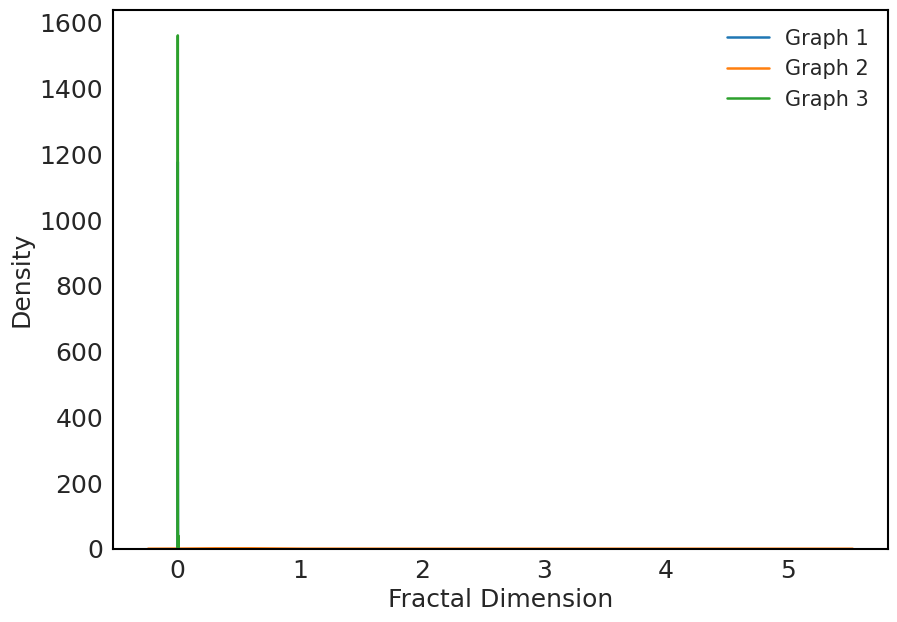

Average fractal dimension for Graph 1: 0.000552118554915476
Average fractal dimension for Graph 2: 0.5528517883803383
Average fractal dimension for Graph 3: 0.0003989853626276922
Average fractal dimension for Graph 4: 0.8191589458315638
Average fractal dimension for Graph 5: 0.3795032985457539


In [ ]:
nfd_centrality_list = []
avg_frac = []
for G in G_list:
    nfd_centrality = node_dimension(G, weight=True).values()
    nfd_centrality_list.append(list(nfd_centrality))
    avg_frac.append(np.mean(np.array(nfd_centrality_list[-1])))

plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(10, 7))
plt.grid(False)

for i, t in enumerate(["Graph 1", "Graph 2", "Graph 3"]):  # Adjust names as needed
    sns.kdeplot(list(nfd_centrality_list[i]), linewidth=1.8, label=t, color=f"C{i}")

plt.legend(frameon=False, loc='best', fontsize=15)
plt.xlabel('Fractal Dimension')
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')

plt.show()

for i, avg in enumerate(avg_frac):
    print(f"Average fractal dimension for Graph {i + 1}: {avg}")

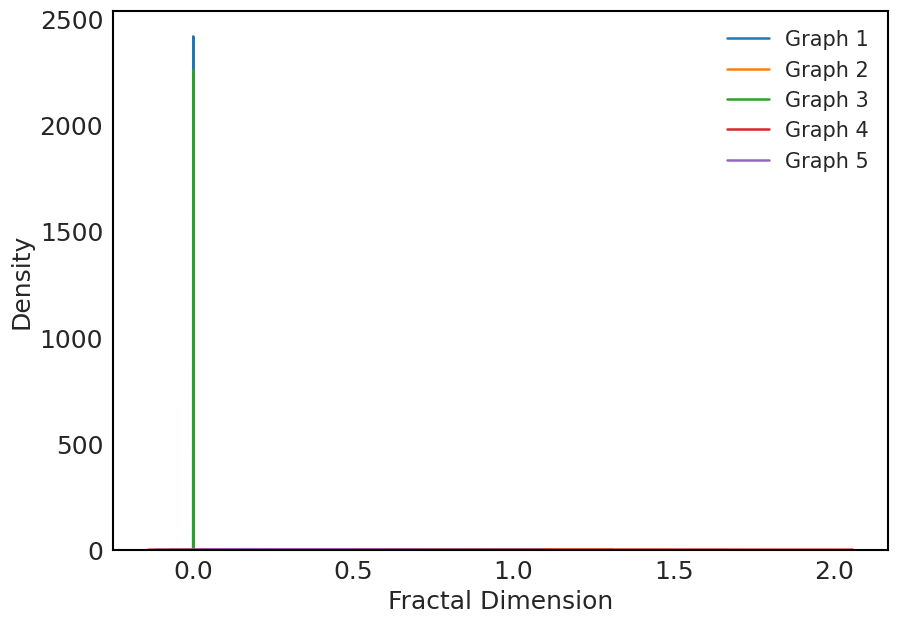

In [ ]:
def remove_outliers(data):
    """Remove outliers from a list using the IQR method."""
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return [x for x in data if lower_bound <= x <= upper_bound]

nfd_centrality_list_no_outliers = [remove_outliers(nfd_data) for nfd_data in nfd_centrality_list]

name = [f"Graph {i+1}" for i in range(len(nfd_centrality_list_no_outliers))]

plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(10, 7))
plt.grid(False)

for i, t in enumerate(name):
    sns.kdeplot(list(nfd_centrality_list_no_outliers[i]), linewidth=1.8, label=t, color=f"C{i}")

plt.legend(frameon=False, loc='best', fontsize=15)
plt.xlabel('Fractal Dimension')

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')

plt.show()

### 3.3 Closeness centrality

In [ ]:
# Closeness centrality
closeness_centrality_list = []
avg_closeness = []
for G in tqdm(G_list):
    closeness_centrality = nx.closeness_centrality(G,distance='weight').values()
    closeness_centrality_list.append(list(closeness_centrality))
    avg_closeness.append(np.mean(np.array(closeness_centrality_list[-1])))

100%|██████████| 5/5 [00:10<00:00,  2.20s/it]


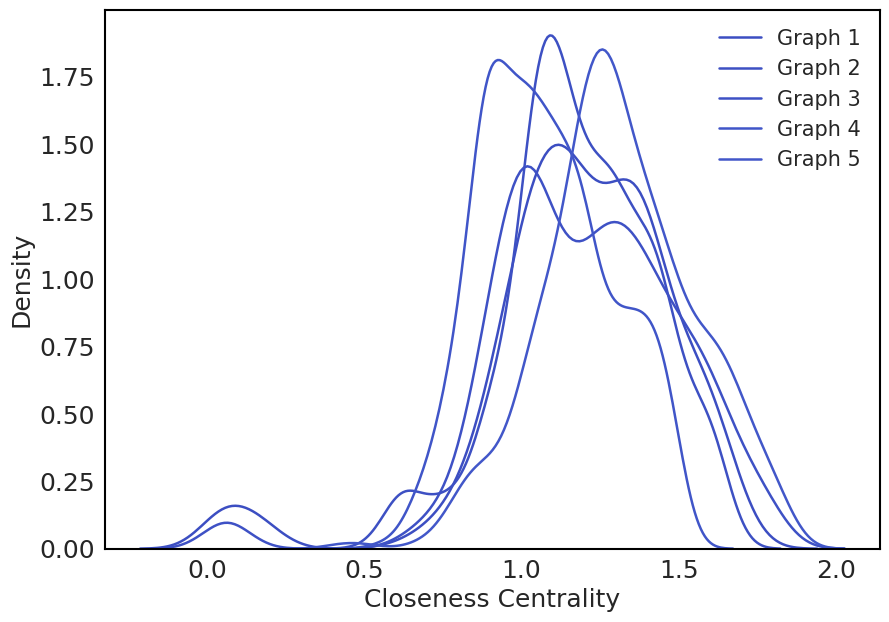

In [ ]:
plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(10,7))
plt.grid(False)
for i,t in enumerate(name): #Peiyu:modify
    sns.kdeplot(list(closeness_centrality_list[i]),linewidth=1.8, label=t,color=colors[i])

plt.legend(frameon=False,loc='best',fontsize=15)
#plt.ylim([0,2.1])
plt.xlabel('Closeness Centrality')

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')

# plt.savefig(root+'weighted_closeness_80kX.svg',bbox_inches = 'tight',dpi=600)
plt.show()

### 3.4 Degree centrality

In [ ]:
# Degree centrality
degree_centrality_list = []
avg_degree = []

for G in tqdm(G_list):
    degree_centrality = dict(G.degree(weight='weight')).values()
    degree_centrality_list.append(list(degree_centrality))
    avg_degree.append(np.mean(np.array(degree_centrality_list[-1])))


100%|██████████| 5/5 [00:00<00:00, 582.54it/s]


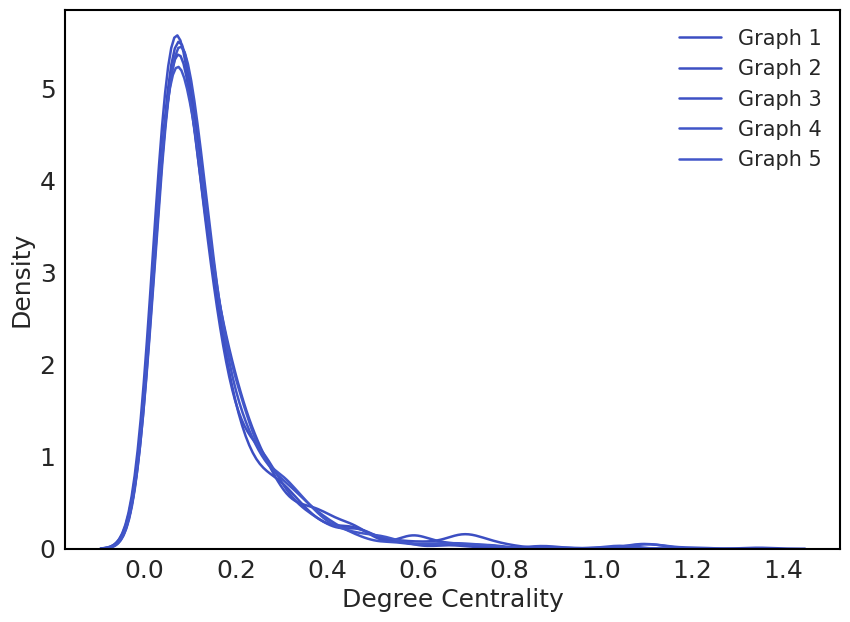

In [ ]:
plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(10,7))
plt.grid(False)
# plt.title('Video 1: Reference')
for i,t in enumerate(name): #Peiyu:modify
    sns.kdeplot(list(degree_centrality_list[i]),linewidth=1.8, label=t,color=colors[i])

plt.legend(frameon=False,loc='best',fontsize=15)
#plt.ylim([0,2.1])
plt.xlabel('Degree Centrality')

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')

# plt.savefig(root+'weighted_degree_80kX.svg',bbox_inches = 'tight',dpi=600)
plt.show()

### 3.5 Clustering coefficient

In [ ]:
# Clustering coefficient
cluster_coef_list = []

avg_clustering = []

for G in tqdm(G_list):
    cluster_coef = nx.clustering(G, weight='weight').values()
    cluster_coef_list.append(list(cluster_coef))
    avg_clustering.append(np.mean(np.array(cluster_coef_list[-1])))

100%|██████████| 5/5 [00:00<00:00, 45.52it/s]


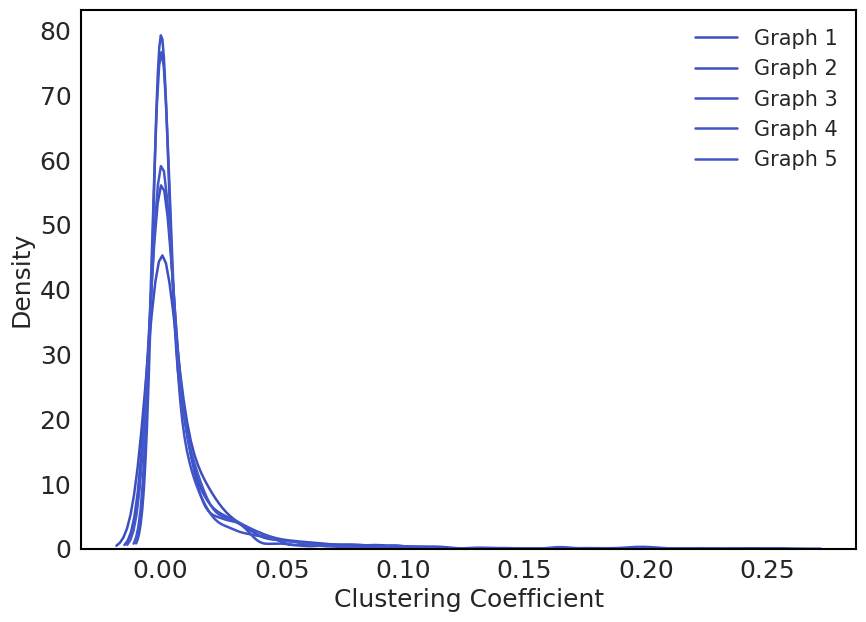

In [ ]:
plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(10,7))
plt.grid(False)
# plt.title('Video 1: Reference')
for i,t in enumerate(name): #Peiyu:modify
    sns.kdeplot(list(cluster_coef_list[i]),linewidth=1.8, label=t,color=colors[i])

plt.legend(frameon=False,loc='best',fontsize=15)
#plt.ylim([0,2.1])
plt.xlabel('Clustering Coefficient')

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')

# plt.savefig(root+'weighted_clustering_80kX.svg',bbox_inches = 'tight',dpi=600)
plt.show()

### 3.6 Betweeness

In [ ]:

# Calculate average betweenness centrality
betweenness_list = []
avg_betweenness_list = []
for G_nx in tqdm(G_list):
    G = nk.nxadapter.nx2nk(G_nx, weightAttr='weight')
    betweenness = nk.centrality.Betweenness(G, normalized=True).run()
    betweenness_list.append(betweenness.scores())
    avg_betweenness = sum(betweenness.scores()) / G.numberOfNodes()
    avg_betweenness_list.append(avg_betweenness)

100%|██████████| 5/5 [00:00<00:00, 11.12it/s]


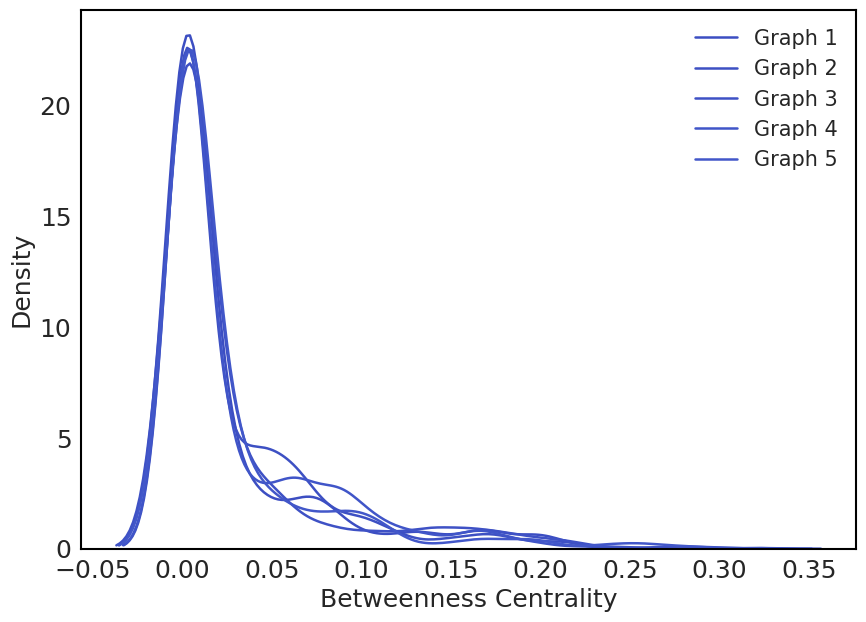

In [ ]:
plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(10,7))
plt.grid(False)
# plt.title('Video 1: Reference')
for i,t in enumerate(name): #Peiyu:modify
    sns.kdeplot(list(betweenness_list[i]),linewidth=1.8, label=t,color=colors[i])

plt.legend(frameon=False,loc='best',fontsize=15)
#plt.ylim([0,2.1])
plt.xlabel('Betweenness Centrality')

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')

# plt.savefig(root+'weighted_betweenness_80kX.svg',bbox_inches = 'tight',dpi=600)
plt.show()

### 3.7 Graph Ollivier-Ricci

In [ ]:
%pip install GraphRicciCurvature
%pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 835.4/835.4 kB 40.0 MB/s eta 0:00:00


In [ ]:
from GraphRicciCurvature.OllivierRicci import OllivierRicci

In [ ]:
avg_orcs = []
orc_list = []
for G in tqdm(G_list):
  avg_orc = []
  orc = OllivierRicci(nx.convert_node_labels_to_integers(G), alpha=0.5, verbose="ERROR")
  # 计算Ollivier-Ricci曲率
  orc.compute_ricci_curvature()
  G_orc = orc.G.copy()
  # 输出每条边的Ollivier-Ricci曲率
  for (u, v, d) in G_orc.edges(data=True):
    avg_orc.append(d['ricciCurvature'])
  orc_list.append(avg_orc)
  avg_orcs.append(np.mean(np.array(avg_orc)))

  0%|          | 0/5 [00:00<?, ?it/s]/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
100%|██████████| 5/5 [00:02<00:00,  1.78it/s]


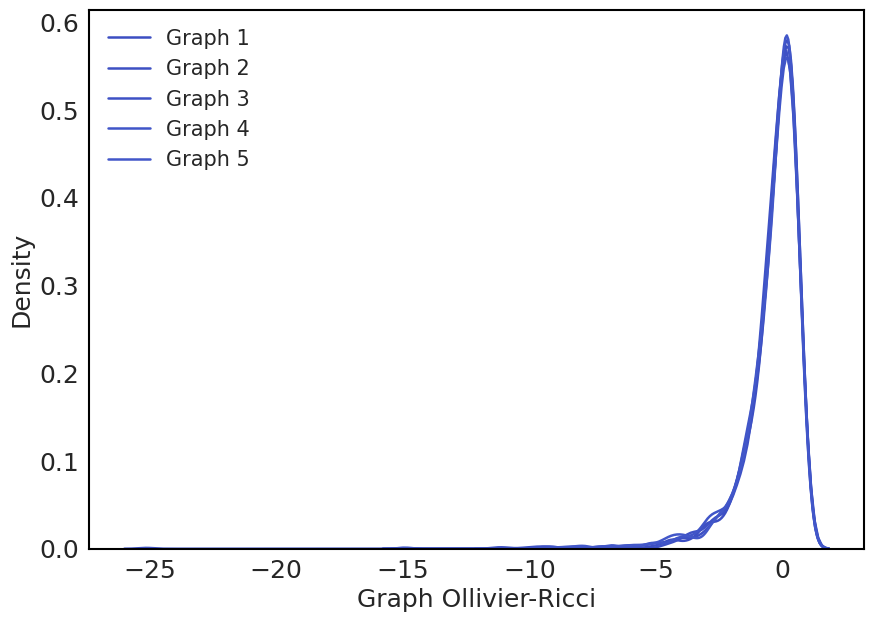

In [ ]:
plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(10,7))
plt.grid(False)
# plt.title('Video 1: Reference')
for i,t in enumerate(name): #Peiyu:modify
    sns.kdeplot(list(orc_list[i]),linewidth=1.8, label=t,color=colors[i])

plt.legend(frameon=False,loc='best',fontsize=15)
#plt.ylim([0,2.1])
plt.xlabel('Graph Ollivier-Ricci')

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')

# plt.savefig(root+'weighted_Ollivier-Ricci_80kX.svg',bbox_inches = 'tight',dpi=600)
plt.show()

#   

#   

#     

# Archieved Code (OLD)

## Load Graph

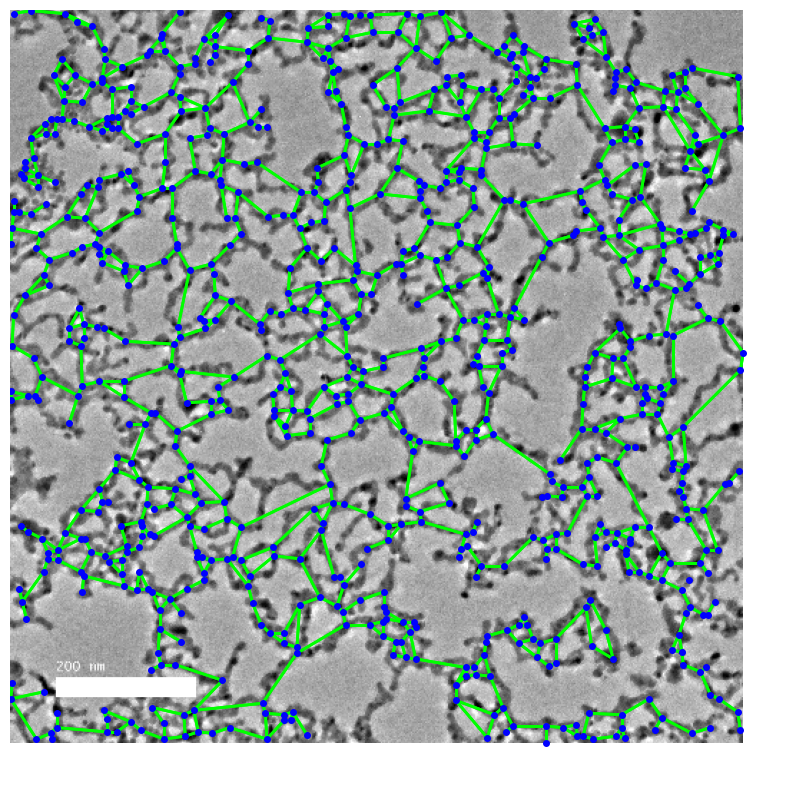

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Load network data
network_path = '/content/drive/MyDrive/vis/20kX/sparse_matrices_20kX_new.npz'
network_data = np.load(network_path, allow_pickle=True)
edges = network_data['A'].item()  # Assuming A is a list of edges (i, j, weight)
rows, cols = edges.nonzero()

# Load node positions_of_nodes
positions_path = '/content/drive/MyDrive/vis/20kX_postion.npy'
positions = np.load(positions_path, allow_pickle=True)
positions[:, [0, 1]] = positions[:, [1, 0]]  # Swap columns to fit the plotting needs

# Get min and max coordinates for normalization
min_x = positions[:, 0].min()
max_x = positions[:, 0].max()
min_y = positions[:, 1].min()
max_y = positions[:, 1].max()

# Normalize function
def normalize(value, min_value, max_value):
    return (value - min_value) / (max_value - min_value)

# Load and resize original_image
canvas_image_path = '/content/drive/MyDrive/vis/20kX/Copy of 300kV 20kX  Pre-GIF 2045.tif'
raw_src = cv2.imread(canvas_image_path, cv2.IMREAD_GRAYSCALE)

h, w = raw_src.shape
scalefactor = 512 / max(w, h)
swidth = int(scalefactor * w)
sheight = int(scalefactor * h)
dsize = (swidth, sheight)
canvas_image_gray = cv2.resize(raw_src, dsize)

canvas_height, canvas_width = canvas_image_gray.shape

# Normalize and scale positions_of_nodes
scaled_positions = np.zeros_like(positions)
scaled_positions[:, 0] = normalize(positions[:, 0], min_x, max_x) * canvas_width
scaled_positions[:, 1] = normalize(positions[:, 1], min_y, max_y) * canvas_height

# Convert positions_of_nodes to a dictionary for easier access
position_dict = {i: pos for i, pos in enumerate(scaled_positions)}

# Plot original_image and network
plt.figure(figsize=(10, 10))
plt.imshow(canvas_image_gray, cmap='gray')

# Plot edges
for s, e in zip(rows, cols):
    if s in position_dict and e in position_dict:
        x1, y1 = position_dict[s]
        x2, y2 = position_dict[e]
        plt.plot([x1, x2], [y1, y2], color='lime', linewidth=2)

# Plot nodes
for (x, y) in scaled_positions:
    plt.plot(x, y, 'bo', markersize=4)

plt.axis('off')
plt.show()

### Properties (OLD)

#### Basic properties

In [ ]:
rows, cols

(array([  0,   0,   1, ..., 844, 844, 845]),
 array([  1,   6,   0, ..., 836, 837, 818]))

In [ ]:
len(rows), len(cols)

(2214, 2214)

In [ ]:
len(positions)

846

#### Bidirectional

In [ ]:
edges = set(zip(rows, cols))

def verify_doubled_edges(edges):
    for s, e in edges:
        if (e, s) not in edges:
            print(f"Edge ({s}, {e}) does not have a corresponding ({e}, {s})")
            return False
    return True

all_doubled = verify_doubled_edges(edges)
print(f"All edges are bidirectional: {all_doubled}")

All edges are bidirectional: True


Since we know it's bidirectional, we can use indegree to represent

## Calculation on the probabilty distribuition on the Degree, Angles _P(Angle|Degree)_, Lengths _P(Length|Degree)_

### Distribution of all angles (OLD)

In [ ]:
# In Degree
degree_count = defaultdict(int)
for s, e in zip(rows, cols):
    degree_count[s] += 1

# Group nodes by degree
nodes_by_degree = defaultdict(list)
for node, degree in degree_count.items():
    nodes_by_degree[degree].append(node)

# Adjacent Dictionary
neighbors_dict = defaultdict(set)
for s, e in zip(rows, cols):
    neighbors_dict[s].add(e)
    neighbors_dict[e].add(s)


degree_edge_lengths = defaultdict(list)
degree_angles = defaultdict(list)

def calculate_distance(p1, p2):
    return np.linalg.norm(np.array(p1) - np.array(p2))

# Normalize coordinates to avoid overflow
normalized_positions = {node: np.array(position, dtype=np.float64) for node, position in position_dict.items()}

for node, node_pos in normalized_positions.items():
    neighbors = list(neighbors_dict[node])

    # Calculate lengths of edges
    lengths = [calculate_distance(node_pos, normalized_positions[n]) for n in neighbors]
    degree_edge_lengths[degree_count[node]].extend(lengths)

    if len(neighbors) > 1:
        # Convert neighbors to polar coordinates (angle relative to the node)
        polar_coords = [(n, np.arctan2(np.float64(normalized_positions[n][1] - node_pos[1]), np.float64(normalized_positions[n][0] - node_pos[0])))
        for n in neighbors]

        # Sort neighbors by their polar angle
        polar_coords.sort(key=lambda x: x[1])

        # Calculate angles between adjacent edges
        angles = []
        for i in range(len(polar_coords)):
            angle_diff = (polar_coords[(i + 1) % len(polar_coords)][1] - polar_coords[i][1]) * (180 / np.pi)
            if angle_diff < 0:
                angle_diff += 360
            angles.append(round(angle_diff, 0))

        degree_angles[degree_count[node]].extend(angles)

In [ ]:
class GraphNode:
    degree_distribution = []
    degree_angles = {}
    degree_edge_lengths = {}
    existing_edges = []

    def __init__(self, position, *, parent=None, parent_angle=None):
        self.position = position
        self.degree = random.choice(GraphNode.degree_distribution)
        self.parent = parent
        self.children = []

        if self.parent is None and parent_angle is None:
            # Root node: start from a random angle as the base
            self.base_angle = random.uniform(0, 360)
        elif self.parent is not None and parent_angle is not None:
            # Non-root node: start from the angle opposite to the parent connection
            self.base_angle = (parent_angle + 180) % 360
            self.children.append(self.parent)  # Add parent as the first child
        else:
            raise ValueError("Both parent and parent_angle must be provided together or not at all.")

    def add_child(self, child):
        self.children.append(child)

    def generate_children(self):
        if self.degree == 1:
            return  # Endpoints have no children

        angles, lengths = self.generate_angles_and_lengths()
        children_positions = self.polar_to_cartesian(lengths, angles)

        for child_position, angle in zip(children_positions, angles):
            child_node = GraphNode(child_position, parent=self, parent_angle=angle)
            new_edge = (self.position, child_position)
            if not self.check_intersection(new_edge):
                self.add_child(child_node)
                GraphNode.existing_edges.append(new_edge)
            # else:
                # print(f"Node at {child_node.position} aborted due to intersection")

    def generate_angles_and_lengths(self):
        angles = []
        if self.degree > 0:
            # Generate the first angle as random + base_angle
            angle = round(self.base_angle + random.choice(GraphNode.degree_angles[self.degree]), 2)
            angles.append(angle)
            # Generate subsequent angles based on the previous angle
            for _ in range(1, self.degree):
                angle = round(angle + random.choice(GraphNode.degree_angles[self.degree]), 2)
                angles.append(angle)
        lengths = [round(length, 2) for length in random.choices(GraphNode.degree_edge_lengths[self.degree], k=self.degree)]
        return angles, lengths

    def polar_to_cartesian(self, lengths, angles):
        x, y = self.position
        cartesian_coords = []
        for length, angle in zip(lengths, angles):
            angle_rad = np.deg2rad(angle)
            new_x = x + length * np.cos(angle_rad)
            new_y = y + length * np.sin(angle_rad)
            cartesian_coords.append((new_x, new_y))
        return cartesian_coords

    @staticmethod
    def do_intersect(p1, q1, p2, q2):
        def orientation(p, q, r):
            val = (q[1] - p[1]) * (r[0] - q[0]) - (q[0] - p[0]) * (r[1] - q[1])
            if val == 0:
                return 0
            elif val > 0:
                return 1
            else:
                return 2

        def on_segment(p, q, r):
            if min(p[0], r[0]) <= q[0] <= max(p[0], r[0]) and min(p[1], r[1]) <= q[1] <= max(p[1], r[1]):
                return True
            return False

        o1 = orientation(p1, q1, p2)
        o2 = orientation(p1, q1, q2)
        o3 = orientation(p2, q2, p1)
        o4 = orientation(p2, q2, q1)

        if o1 != o2 and o3 != o4:
            return True

        if o1 == 0 and on_segment(p1, p2, q1):
            return True

        if o2 == 0 and on_segment(p1, q2, q1):
            return True

        if o3 == 0 and on_segment(p2, p1, q2):
            return True

        if o4 == 0 and on_segment(p2, q1, q2):
            return True

        return False

    def check_intersection(self, new_edge):
        for edge in GraphNode.existing_edges:
            if new_edge[0] == edge[0] or new_edge[0] == edge[1] or new_edge[1] == edge[0] or new_edge[1] == edge[1]:
                continue  # Skip edges with the same parent
            if GraphNode.do_intersect(new_edge[0], new_edge[1], edge[0], edge[1]):
                return True
        return False

GraphNode.degree_distribution = list(degree_count.values())
GraphNode.degree_angles = degree_angles
GraphNode.degree_edge_lengths = degree_edge_lengths

### Conditional Probabilites on degrees (degrees|degress)

#### Naive stat of degrees (OLD)

In [ ]:
# In Degree
degree_count = defaultdict(int)
for s, e in zip(rows, cols):
    degree_count[s] += 1

# Group nodes by degree
nodes_by_degree = defaultdict(list)
for node, degree in degree_count.items():
    nodes_by_degree[degree].append(node)

# Adjacent Dictionary
neighbors_dict = defaultdict(set)
for s, e in zip(rows, cols):
    neighbors_dict[s].add(e)
    neighbors_dict[e].add(s)


degree_edge_lengths = defaultdict(list)
degree_angles = defaultdict(list)

def calculate_distance(p1, p2):
    return np.linalg.norm(np.array(p1) - np.array(p2))

# Normalize coordinates to avoid overflow
normalized_positions = {node: np.array(position, dtype=np.float64) for node, position in position_dict.items()}

for node, node_pos in normalized_positions.items():
    neighbors = list(neighbors_dict[node])

    lengths = [calculate_distance(node_pos, normalized_positions[n]) for n in neighbors]
    degree_edge_lengths[degree_count[node]].extend(lengths)

    if len(neighbors) > 1:
        # Convert neighbors to polar coordinates (angle relative to the node)
        polar_coords = [(n, np.arctan2(np.float64(normalized_positions[n][1] - node_pos[1]), np.float64(normalized_positions[n][0] - node_pos[0])))
        for n in neighbors]

        # Sort neighbors by their polar angle
        polar_coords.sort(key=lambda x: x[1])

        # Calculate angles between adjacent edges
        angles = []
        for i in range(len(polar_coords)):
            angle_diff = (polar_coords[(i + 1) % len(polar_coords)][1] - polar_coords[i][1]) * (180 / np.pi)
            if angle_diff < 0:
                angle_diff += 360
            angles.append(round(angle_diff, 0))

        # Remove the largest angle since the last angle is dependent
        # if len(angles) == degree_count[node]:
        #     angles.remove(max(angles))

        degree_angles[degree_count[node]].extend(angles)

#### Conditional Stat of degrees

In [ ]:
# In Degree
in_degree_count = defaultdict(int)
for start, end in zip(rows, cols):
    in_degree_count[start] += 1
in_degree_count = {node: degree for node, degree in in_degree_count.items() if degree > 0}

# Group nodes by degree
nodes_by_degree = defaultdict(list)
for node, degree in in_degree_count.items():
    nodes_by_degree[degree].append(node)

# Calculate degree probabilities
total_nodes = len(in_degree_count)
degree_probabilities = {degree: len(nodes) / total_nodes for degree, nodes in nodes_by_degree.items()}

# Adjacency Dictionary
adjacency_dict = defaultdict(set)
for start, end in zip(rows, cols):
    adjacency_dict[start].add(end)
    adjacency_dict[end].add(start)

# Mapping from each degree to the degrees of its connected vertices
degree_neighbors_map = defaultdict(list)
for node, neighbors in adjacency_dict.items():
    node_degree = in_degree_count[node]
    neighbor_degrees = [in_degree_count[neighbor] for neighbor in neighbors]
    degree_neighbors_map[node_degree].extend(neighbor_degrees)

# Calculate degree transition probabilities
degree_transition_probs = {}
for degree, neighbor_degrees in degree_neighbors_map.items():
    degree_distribution = defaultdict(int)
    for neighbor_degree in neighbor_degrees:
        degree_distribution[neighbor_degree] += 1
    total_neighbors = sum(degree_distribution.values())
    degree_transition_probs[degree] = {k: v / total_neighbors for k, v in degree_distribution.items()}

# Degree Edge Lengths and Angles Calculation (Existing Code)
edge_lengths_by_degree = defaultdict(list)
angles_by_degree = defaultdict(list)

def calculate_distance(p1, p2):
    return np.linalg.norm(np.array(p1) - np.array(p2))

normalized_positions = {node: np.array(position, dtype=np.float64) for node, position in position_dict.items()}

for node, node_pos in normalized_positions.items():
    if node not in in_degree_count:
        continue

    neighbors = list(adjacency_dict[node])
    lengths = [calculate_distance(node_pos, normalized_positions[n]) for n in neighbors if n in normalized_positions]
    node_degree = in_degree_count[node]
    if node_degree > 0:
        edge_lengths_by_degree[node_degree].extend(lengths)

    if len(neighbors) > 1:
        # Convert neighbors to polar coordinates (angle relative to the node)
        polar_coords = [(n, np.arctan2(np.float64(normalized_positions[n][1] - node_pos[1]), np.float64(normalized_positions[n][0] - node_pos[0])))
                        for n in neighbors if n in normalized_positions]

        # Sort neighbors by their polar angle
        polar_coords.sort(key=lambda x: x[1])

        # Calculate angles between adjacent edges
        angles = []
        for i in range(len(polar_coords)):
            angle_diff = (polar_coords[(i + 1) % len(polar_coords)][1] - polar_coords[i][1]) * (180 / np.pi)
            if angle_diff < 0:
                angle_diff += 360
            angles.append(round(angle_diff, 0))

        if node_degree > 0:
            angles_by_degree[node_degree].extend(angles)

In [ ]:
degree_transition_probs.keys(), angles_by_degree.keys(), edge_lengths_by_degree.keys()

(dict_keys([2, 3, 1, 4, 5]),
 dict_keys([2, 3, 4, 5]),
 dict_keys([2, 3, 1, 4, 5]))

In [ ]:
total_nodes = sum(len(nodes_by_degree[k]) for k in nodes_by_degree)

for k in sorted(nodes_by_degree.keys()):
    ratio = round(len(nodes_by_degree[k]) / total_nodes, 3)
    print(k, ratio)

1 0.067
2 0.301
3 0.581
4 0.046
5 0.005


#### Plot Distribution (No need to run)

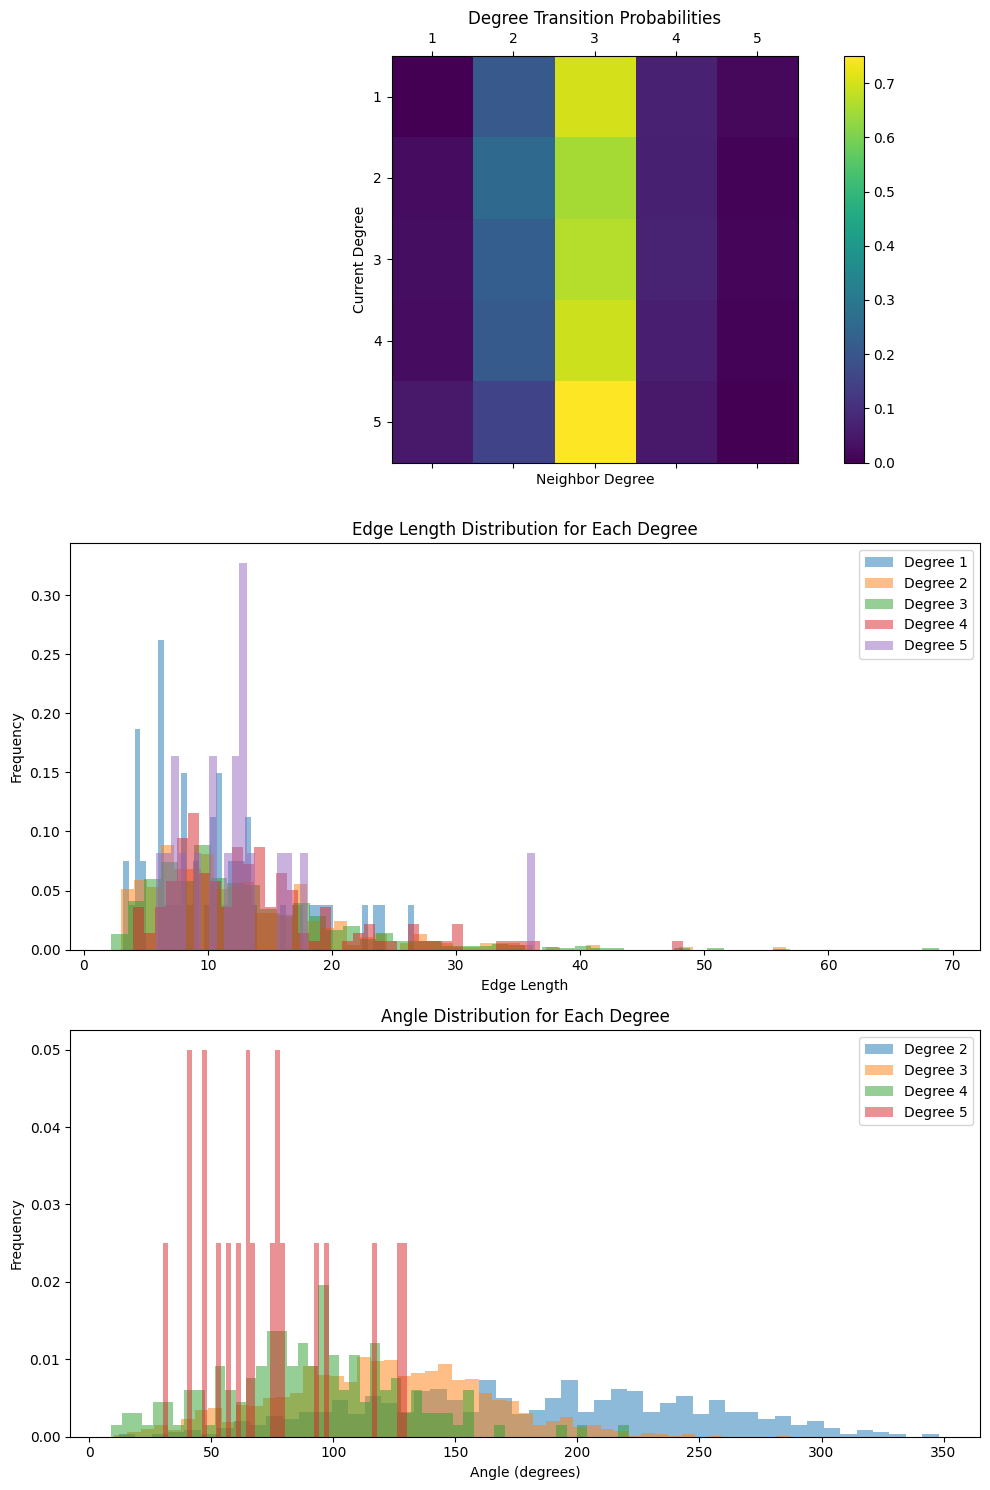

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(10, 15))

degrees = sorted(degree_transition_probs.keys())
transition_matrix = np.zeros((len(degrees), len(degrees)))

for i, degree in enumerate(degrees):
    for j, neighbor_degree in enumerate(degrees):
        transition_matrix[i, j] = degree_transition_probs[degree].get(neighbor_degree, 0)

cax = axs[0].matshow(transition_matrix, cmap='viridis')
fig.colorbar(cax, ax=axs[0])
axs[0].set_xticks(np.arange(len(degrees)))
axs[0].set_yticks(np.arange(len(degrees)))
axs[0].set_xticklabels(degrees)
axs[0].set_yticklabels(degrees)
axs[0].set_xlabel('Neighbor Degree')
axs[0].set_ylabel('Current Degree')
axs[0].set_title('Degree Transition Probabilities')

# Generate and plot random samples for edge lengths
for degree in sorted(edge_lengths_by_degree.keys()):
    if len(edge_lengths_by_degree[degree]) > 0:
        random_lengths = edge_lengths_by_degree[degree]

        axs[1].hist(random_lengths, bins=50, density=True, alpha=0.5, label=f'Degree {degree}')
        axs[1].set_xlabel('Edge Length')
        axs[1].set_ylabel('Frequency')
        axs[1].set_title('Edge Length Distribution for Each Degree')
        axs[1].legend()

# Generate and plot random samples for angles
for degree in sorted(angles_by_degree.keys()):
    if len(angles_by_degree[degree]) > 0:
        random_angles = angles_by_degree[degree]

        axs[2].hist(random_angles, bins=50, density=True, alpha=0.5, label=f'Degree {degree}')
        axs[2].set_xlabel('Angle (degrees)')
        axs[2].set_ylabel('Frequency')
        axs[2].set_title('Angle Distribution for Each Degree')
        axs[2].legend()

plt.tight_layout()
plt.show()

### More Properties (OLD)

#### Length Dist

NameError: name 'degree_edge_lengths' is not defined

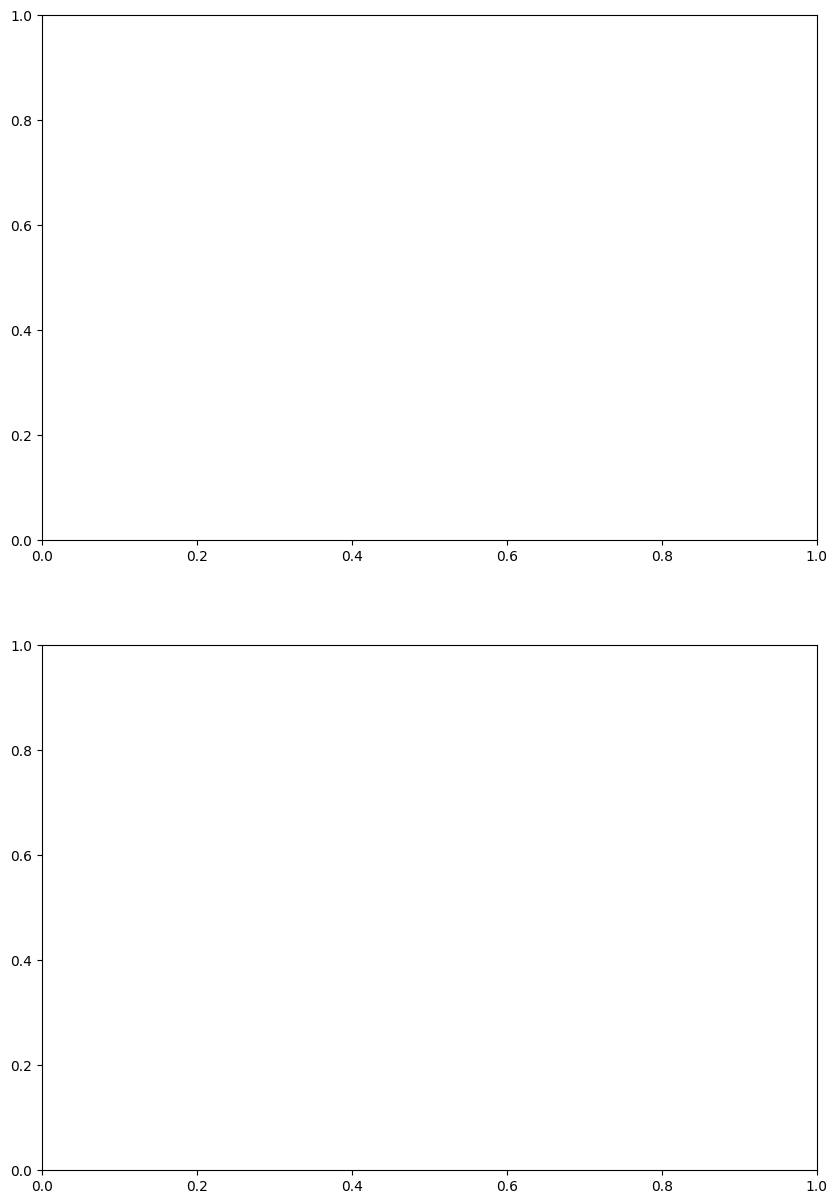

In [ ]:
# Plot distributions for each degree group
fig, axs = plt.subplots(2, 1, figsize=(10, 15))

# Plot edge length distributions
for degree in sorted(nodes_by_degree.keys()):
    if len(degree_edge_lengths[degree]) > 0:
        axs[0].hist(degree_edge_lengths[degree], bins=50, density=True, alpha=0.5, label=f'Degree {degree}')
axs[0].set_xlabel('Edge Length')
axs[0].set_ylabel('Frequency')
axs[0].set_title('Edge Length Distribution for Each Degree')
axs[0].legend()

# Plot angle distributions
for degree in sorted(nodes_by_degree.keys()):
    if len(degree_angles[degree]) > 0:
        axs[1].hist(degree_angles[degree], bins=50, density=True, alpha=0.5, label=f'Degree {degree}')
axs[1].set_xlabel('Angle (degrees)')
axs[1].set_ylabel('Frequency')
axs[1].set_title('Angle Distribution for Each Degree')
axs[1].set_xlim(0, 360)
axs[1].legend()


plt.tight_layout()
plt.show()

In [ ]:
# Function to plot the distributions without histogram outlines
def plot_distributions_no_outline(degree_data, title, xlabel, ylabel):
    plt.figure(figsize=(12, 6))
    for degree, data in degree_data.items():
        sns.histplot(data, bins=5, kde=True, label=f'Degree {degree}', stat="density", common_norm=False, edgecolor=None)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()

# Plot edge length distributions without outlines
plot_distributions_no_outline(degree_edge_lengths, 'Edge Length Distribution for Each Degree', 'Edge Length', 'Density')

# Plot angle distributions without outlines
plot_distributions_no_outline(degree_angles, 'Angle Distribution for Each Degree', 'Angle (degrees)', 'Density')

In [ ]:
# Function to plot the distributions and overlay log-normal fits
def plot_distributions_with_lognorm_fit(degree_data, title, xlabel, ylabel):
    plt.figure(figsize=(12, 6))

    for degree, data in degree_data.items():
        if len(data) == 0:
            continue

        # Fit log-normal distribution
        params_log = lognorm.fit(data)
        x = np.linspace(min(data), max(data), 100)
        pdf_log = lognorm.pdf(x, *params_log)

        # Plot data and fitted log-normal model
        sns.histplot(data, bins=5, kde=True, label=f'Degree {degree}', stat="density", common_norm=False, edgecolor=None)
        plt.plot(x, pdf_log, label=f'Log-Normal Fit (Degree {degree})', linestyle='--')

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()

# Plot edge length distributions with log-normal fits
plot_distributions_with_lognorm_fit(degree_edge_lengths, 'Edge Length Distribution for Each Degree', 'Edge Length', 'Density')

In [ ]:
# Convert the defaultdict to a regular dictionary for storage
degree_edge_lengths_dict = dict(degree_edge_lengths)
degree_angles_dict = dict(degree_angles)

# Save the data to an npz file
np.savez('degree_distributions.npz', degree_edge_lengths=degree_edge_lengths_dict, degree_angles=degree_angles_dict)

# To verify, you can load the file and check its contents
loaded_data = np.load('degree_distributions.npz', allow_pickle=True)
print(loaded_data.files)
print(loaded_data['degree_edge_lengths'].item())
print(loaded_data['degree_angles'].item())

### Weight vs Length

#### (OLD)

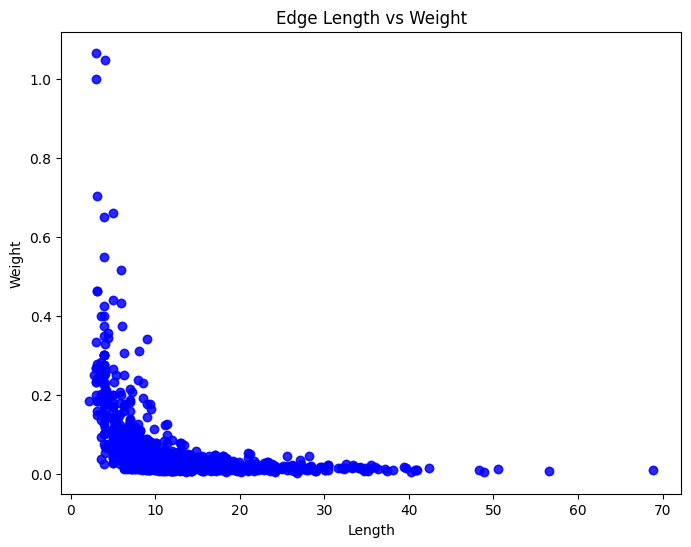

In [ ]:
in_degree_count = defaultdict(int)
for start, end in zip(rows, cols):
    in_degree_count[start] += 1
in_degree_count = {node: degree for node, degree in in_degree_count.items() if degree > 0}

adjacency_dict = defaultdict(set)
for start, end in zip(rows, cols):
    adjacency_dict[start].add(end)
    adjacency_dict[end].add(start)

edge_lengths = []
edge_weights = []

def calculate_distance(p1, p2):
    return np.linalg.norm(np.array(p1) - np.array(p2))

# Normalize the positions_of_nodes (already done in your code)
normalized_positions = {node: np.array(position, dtype=np.float64) for node, position in position_dict.items()}

# Iterate through the nodes and their neighbors to calculate lengths and associate weights
for node, node_pos in normalized_positions.items():
    if node not in in_degree_count:
        continue

    neighbors = list(adjacency_dict[node])
    for neighbor in neighbors:
        if neighbor in normalized_positions:
            length = calculate_distance(node_pos, normalized_positions[neighbor])
            weight = edges[node, neighbor]

            edge_lengths.append(length)
            edge_weights.append(weight)

plt.figure(figsize=(8, 6))
plt.scatter(edge_lengths, edge_weights, c='blue', alpha=0.6)
plt.title('Edge Length vs Weight')
plt.xlabel('Length')
plt.ylabel('Weight')
plt.grid(False)
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from scipy.optimize import curve_fit

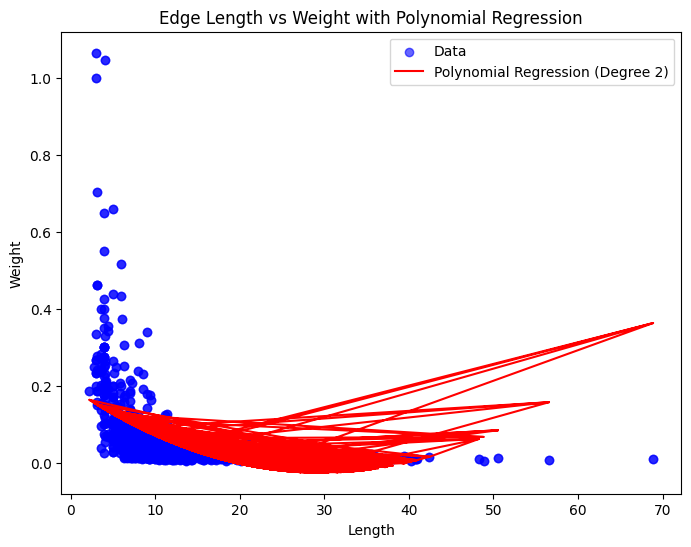

In [ ]:
X = np.array(edge_lengths).reshape(-1, 1)
y = np.array(edge_weights)

# Try a polynomial regression of degree 2 or 3
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

y_poly_pred = model.predict(X_poly)

plt.figure(figsize=(8, 6))
plt.scatter(X, y, c='blue', alpha=0.6, label='Data')
plt.plot(X, y_poly_pred, color='red', label='Polynomial Regression (Degree 2)')
plt.title('Edge Length vs Weight with Polynomial Regression')
plt.xlabel('Length')
plt.ylabel('Weight')
plt.legend()
plt.grid(False)
plt.show()

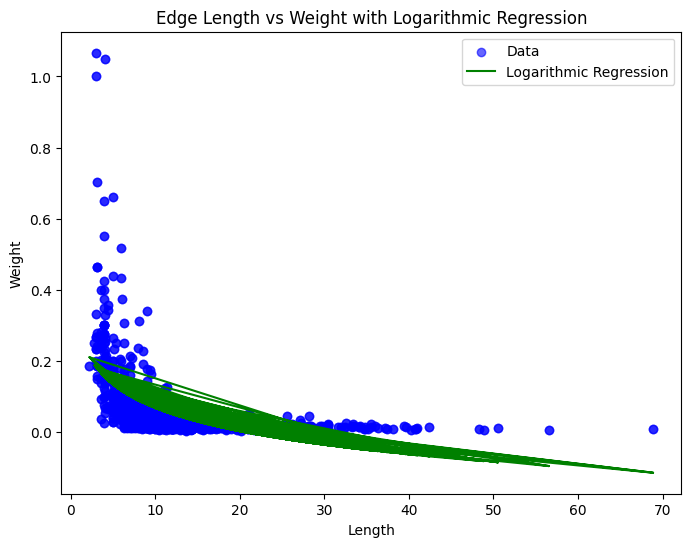

In [ ]:
def log_func(x, a, b):
    return a * np.log(x) + b

params, covariance = curve_fit(log_func, X.flatten(), y)

# Predict using the logarithmic model
y_log_pred = log_func(X.flatten(), *params)

plt.figure(figsize=(8, 6))
plt.scatter(X, y, c='blue', alpha=0.6, label='Data')
plt.plot(X, y_log_pred, color='green', label='Logarithmic Regression')
plt.title('Edge Length vs Weight with Logarithmic Regression')
plt.xlabel('Length')
plt.ylabel('Weight')
plt.legend()
plt.grid(False)
plt.show()

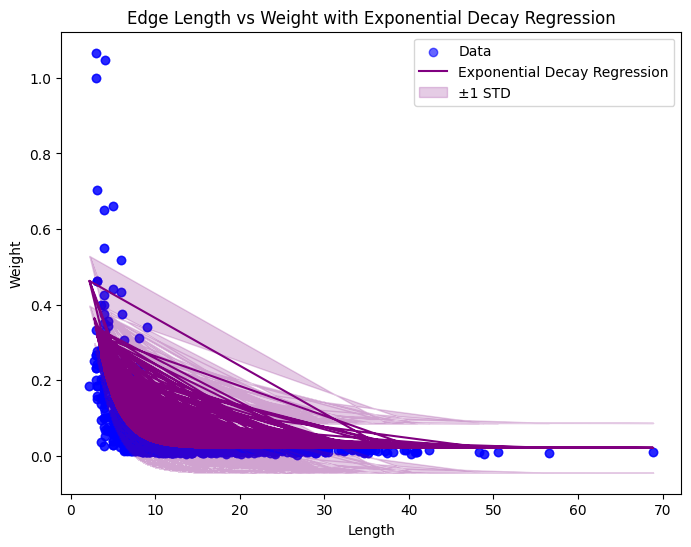

In [ ]:
def exp_func(x, a, b, c):
    return a * np.exp(-b * x) + c

params_exp, covariance_exp = curve_fit(exp_func, X.flatten(), y, p0=(1, 0.1, 1))

# Predict using the exponential model
y_exp_pred = exp_func(X.flatten(), *params_exp)

residuals_exp = y - y_exp_pred
std_exp = np.std(residuals_exp)

plt.figure(figsize=(8, 6))
plt.scatter(X, y, c='blue', alpha=0.6, label='Data')
plt.plot(X, y_exp_pred, color='purple', label='Exponential Decay Regression')
plt.fill_between(X.flatten(), y_exp_pred - std_exp, y_exp_pred + std_exp, color='purple', alpha=0.2, label='±1 STD')
plt.title('Edge Length vs Weight with Exponential Decay Regression')
plt.xlabel('Length')
plt.ylabel('Weight')
plt.legend()
plt.grid(False)
plt.show()

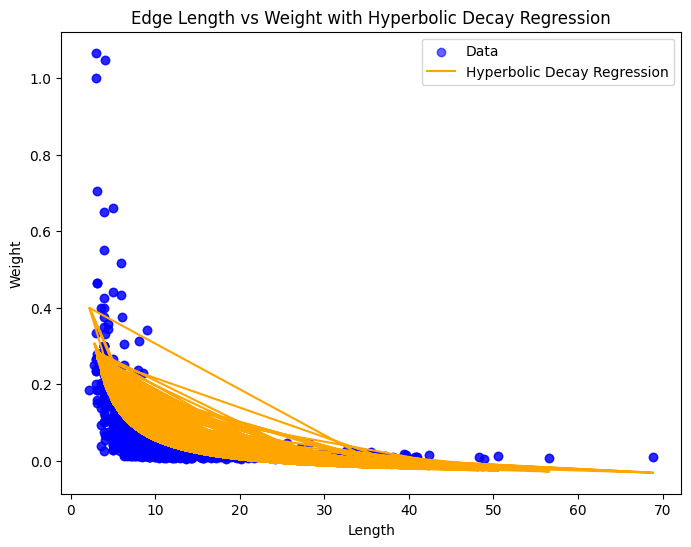

In [ ]:
def hyperbolic_func(x, a, b):
    return a / x + b

X = np.array(edge_lengths).reshape(-1, 1).flatten()  # Flatten to make sure it's a 1D array
y = np.array(edge_weights)

params, covariance = curve_fit(hyperbolic_func, X, y)

# Predict using the hyperbolic model
y_hyperbolic_pred = hyperbolic_func(X, *params)

plt.figure(figsize=(8, 6))
plt.scatter(X, y, c='blue', alpha=0.6, label='Data')
plt.plot(X, y_hyperbolic_pred, color='orange', label='Hyperbolic Decay Regression')
plt.title('Edge Length vs Weight with Hyperbolic Decay Regression')
plt.xlabel('Length')
plt.ylabel('Weight')
plt.legend()
plt.grid(False)
plt.show()

In [ ]:
def exp_func(x, a, b, c):
    return a * np.exp(-b * x) + c

def hyperbolic_func(x, a, b):
    return a / x + b

X = np.array(edge_lengths).reshape(-1, 1).flatten()  # Flatten to make sure it's a 1D array
y = np.array(edge_weights)

# Fit the exponential decay model
params_exp, covariance_exp = curve_fit(exp_func, X, y, p0=(1, 0.1, 1))
y_exp_pred = exp_func(X, *params_exp)

# Fit the hyperbolic decay model
params_hyp, covariance_hyp = curve_fit(hyperbolic_func, X, y)
y_hyp_pred = hyperbolic_func(X, *params_hyp)

# Calculate standard deviation
residuals_exp = y - y_exp_pred
residuals_hyp = y - y_hyp_pred
std_exp = np.std(residuals_exp)
std_hyp = np.std(residuals_hyp)
print(f"Standard Deviation (Exponential): {std_exp}")
print(f"Standard Deviation (Hyperbolic): {std_hyp}")

Standard Deviation (Exponential): 0.06589374280864806
Standard Deviation (Hyperbolic): 0.06819300848437596


#### Bin-based Mapping

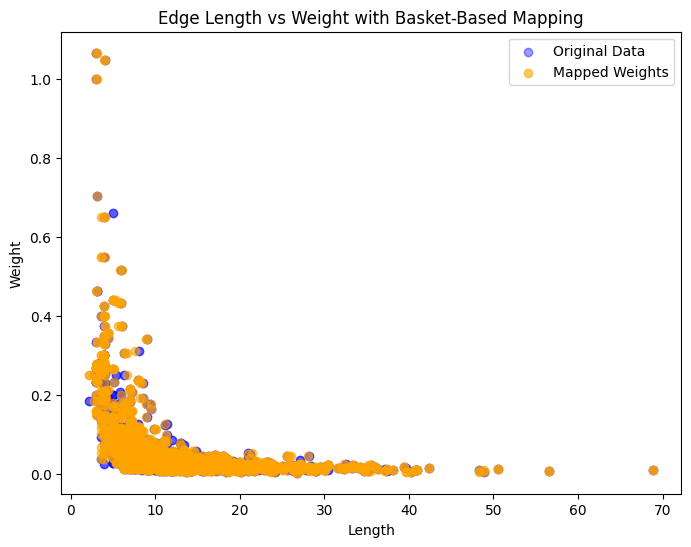

In [ ]:
X = np.array(edge_lengths).reshape(-1, 1).flatten()
y = np.array(edge_weights)

# Nubmer of bins
num_bins = 100

length_bins = np.linspace(X.min(), X.max(), num_bins + 1)
weight_baskets = {i: [] for i in range(num_bins)}

for length, weight in zip(X, y):
    bin_idx = np.digitize(length, length_bins) - 1
    bin_idx = np.clip(bin_idx, 0, num_bins - 1)
    weight_baskets[bin_idx].append(weight)

def map_length_to_weight(length):
    bin_idx = np.digitize(length, length_bins) - 1
    bin_idx = np.clip(bin_idx, 0, num_bins - 1)

    if weight_baskets[bin_idx]:
        return random.choice(weight_baskets[bin_idx])
    else:
        return np.mean(y)

mapped_weights = [map_length_to_weight(length) for length in X]

plt.figure(figsize=(8, 6))
plt.scatter(X, y, c='blue', alpha=0.4, label='Original Data')
plt.scatter(X, mapped_weights, c='orange', alpha=0.6, label='Mapped Weights')
plt.title('Edge Length vs Weight with Basket-Based Mapping')
plt.xlabel('Length')
plt.ylabel('Weight')
plt.legend()
plt.grid(False)
plt.show()

In [ ]:
G = nx.Graph()
for s, e in zip(rows, cols):
    G.add_edge(s, e)

# Calculate degree distribution
degrees = dict(G.degree())
unique_degrees, counts = np.unique(list(degrees.values()), return_counts=True)
degree_distribution = dict(zip(unique_degrees, counts / sum(counts)))

print("In Original Graph the distribution is:")
for k in sorted(degree_distribution.keys()):
    ratio = round(degree_distribution[k], 3)
    print(f"- {k}: {ratio}")

mean_num_nodes = G.number_of_nodes()
mean_num_edges = G.number_of_edges()
print(f"Mean number of nodes in Original Graph: {mean_num_nodes}")
print(f"Mean number of edges in Original Graph: {mean_num_edges}")
closeness_centrality = nx.closeness_centrality(G)
avg_closeness_centrality = np.mean(list(closeness_centrality.values()))
print(f"Average closeness centrality in Original Graph: {avg_closeness_centrality}")

In Original Graph the distribution is:
- 1: 0.067
- 2: 0.301
- 3: 0.581
- 4: 0.046
- 5: 0.005
Mean number of nodes in Original Graph: 845
Mean number of edges in Original Graph: 1107
Average closeness centrality in Original Graph: 0.0397462981720554


## Graph Generation

### Util Funcs

In [ ]:
from datetime import datetime
import time

In [ ]:
def timer(func):
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        end = time.time()
        print(f"\n{func.__name__} time taken: {round(end - start, 6)} seconds")
        return result
    return wrapper

### Graph Node - Closest Nodes become children (OLD)


In [ ]:
class GraphNode:
    degree_distribution = []
    degree_transition_probs = {}
    degree_angles = {}
    degree_edge_lengths = {}
    node_grid = defaultdict(set)
    edge_grid = defaultdict(set)
    grid_size = 13
    aborted_edge = 0
    merged_edge = 0
    id_counter = 0

    enable_check_intersection = True
    enable_merge_nodes = True
    enable_clockwise = True
    enable_degree_transition_probs = True
    enable_merge_edges = True

    def __init__(self, position, *, parent=None, parent_angle=None):
        '''
        PRE: param parent and parent_angle must be provided together or not at all.
        POST: The first children of a non-root node is the parent.
        '''
        self.id = GraphNode.id_counter
        GraphNode.id_counter += 1
        self.position = position
        self.clockwise = random.choice([True, False]) if GraphNode.enable_clockwise else True
        self.parent = parent
        self.children = []

        if parent is not None and parent_angle is not None:  # Non-root Node
            self.degree = self.choose_degree_based_on_parent(parent.degree) if GraphNode.enable_degree_transition_probs else random.choice(GraphNode.degree_distribution)
            self.base_angle = (parent_angle + 180) % 360
            self.add_child(self.parent)
        elif parent is None and parent_angle is None:  # Root Node
            self.degree = random.choice(GraphNode.degree_distribution)
            self.base_angle = random.uniform(0, 360)
            self.initialize_root_node()
        else:
            raise ValueError("Both parent and parent_angle must be provided together or not at all.")

    def choose_degree_based_on_parent(self, parent_degree):
        degrees = list(GraphNode.degree_transition_probs[parent_degree].keys())
        probabilities = list(GraphNode.degree_transition_probs[parent_degree].values())
        return np.random.choice(degrees, p=probabilities)

    def initialize_root_node(self):
        length = random.choice(GraphNode.degree_edge_lengths[self.degree])
        child_position = self.polar_to_cartesian([length], [self.base_angle])[0]
        child = GraphNode(child_position, parent=self, parent_angle=self.base_angle)
        edge = (self.position, child_position)
        self.add_child(child)
        self.add_to_grid(self.position)
        self.add_to_grid(child.position)
        self.add_edge_to_grid(edge)

    def add_child(self, child):
        if len(self.children) >= self.degree:
            raise Exception(f"Node {self} cannot have more than {self.degree} children, current children {self.children}")
        self.children.append(child)
        self.add_to_grid(child.position)

    def add_to_grid(self, position):
        key = self.spatial_hash(position)
        GraphNode.node_grid[key].add(self)
        if len(GraphNode.node_grid[key]) > 1000:
            print("Unusual length of nodes collision chain")

    def add_edge_to_grid(self, edge):
        keys = self.edge_spatial_hash(*edge)
        for key in keys:
            GraphNode.edge_grid[key].add(edge)
            if len(GraphNode.edge_grid[key]) > 1000:
                print("Unusual length of edges collision chain")

    def generate_children(self) -> bool:
        if len(self.children) > 1 or self.degree == 1:  # Skip visited nodes or endpoint nodes
            return False

        # Step 1: Find and sort close nodes
        close_nodes_with_distances = self.find_close_node(self.position)
        closest_nodes = sorted(close_nodes_with_distances, key=lambda x: x[1])[:self.degree - 1]

        # Step 2: Connect to the closest existing nodes
        connected_count = 0
        for close_node, _ in closest_nodes:
            if connected_count >= self.degree - 1:
                break
            new_edge = (self.position, close_node.position)
            if not self.check_intersection(new_edge):
                self.add_child(close_node)
                self.add_edge_to_grid(new_edge)
                GraphNode.merged_edge += 1
                connected_count += 1
            else:
                GraphNode.aborted_edge += 1

        # Step 3: Compute and sort potential new positions_of_nodes
        remaining_degree = self.degree - 1 - len(closest_nodes)
        if remaining_degree > 0:
            angles, lengths = self.generate_angles_and_lengths()
            children_positions = self.polar_to_cartesian(lengths, angles)

            # Calculate distances from the new positions_of_nodes to the closest nodes
            positions_with_distances = []
            for pos in children_positions:
                distances_to_existing_children = [np.linalg.norm(np.array(pos) - np.array(child.position)) for child in self.children]
                min_distance = min(distances_to_existing_children) if distances_to_existing_children else float('inf')
                positions_with_distances.append((pos, min_distance))

            # farthest first
            sorted_positions = sorted(positions_with_distances, key=lambda x: x[1], reverse=True)

            # Step 4: Create new nodes at the farthest positions_of_nodes
            for pos, angle in zip(sorted_positions[:remaining_degree], angles[:remaining_degree]):
                if GraphNode.enable_merge_edges and self.find_close_edge(pos[0]):
                    GraphNode.aborted_edge += 1
                    continue
                child_node = GraphNode(pos[0], parent=self, parent_angle=angle)
                new_edge = (self.position, child_node.position)
                if not self.check_intersection(new_edge):
                    self.add_child(child_node)
                    self.add_edge_to_grid(new_edge)
                    self.add_to_grid(child_node.position)
                else:
                    GraphNode.aborted_edge += 1

        return True

    def get_closest_valid_node(self, position):
        close_nodes_with_distances = self.find_close_node(position)
        if close_nodes_with_distances:
            return min(close_nodes_with_distances, key=lambda x: x[1])[0]
        return None

    def find_close_node(self, position, threshold=None):
        threshold = threshold or GraphNode.grid_size * 0.5
        key = self.spatial_hash(position)
        neighboring_keys = [
            (key[0] + dx, key[1] + dy)
            for dx in range(-1, 2)
            for dy in range(-1, 2)
        ]
        close_nodes_with_distances = []
        for neighbor_key in neighboring_keys:
            for node in GraphNode.node_grid[neighbor_key]:
                if node != self and node not in self.children:
                    distance = np.linalg.norm(np.array(node.position) - np.array(position))
                    if distance < threshold:
                        close_nodes_with_distances.append((node, distance))
        return close_nodes_with_distances

    def find_close_edge(self, position, threshold=None):
        key = self.spatial_hash(position)
        neighboring_keys = [
            (key[0] + dx, key[1] + dy)
            for dx in range(-1, 2)
            for dy in range(-1, 2)
        ]
        for neighbor_key in neighboring_keys:
            for edge in GraphNode.edge_grid[neighbor_key]:
                if self.is_non_sibling_edge(edge, position, threshold):
                    return True
        return False

    def generate_angles_and_lengths(self):
        if self.degree == 1:
            return [], []
        angles = random.choices(GraphNode.degree_angles[self.degree], k=self.degree-1)
        angles = np.cumsum(angles) if self.clockwise else np.cumsum([-angle for angle in angles])
        angles = (angles + self.base_angle).tolist()
        lengths = random.choices(GraphNode.degree_edge_lengths[self.degree], k=self.degree-1)
        return angles, lengths

    def polar_to_cartesian(self, lengths, angles):
        x, y = self.position
        cartesian_coords = []
        for length, angle in zip(lengths, angles):
            angle_rad = np.deg2rad(angle)
            new_x = x + length * np.cos(angle_rad)
            new_y = y + length * np.sin(angle_rad)
            cartesian_coords.append((new_x, new_y))
        return cartesian_coords

    def is_non_sibling_edge(self, edge, position, threshold=None):
        threshold = threshold or GraphNode.grid_size*.8
        if self.parent and (self.parent.position in edge or self.position in edge):
            return False  # Skip edges from the same parent
        p1, p2 = edge
        distances = [
            np.linalg.norm(np.array(position) - np.array(p1)),
            np.linalg.norm(np.array(position) - np.array(p2))
        ]
        return any(distance < threshold for distance in distances)

    def check_intersection(self, new_edge):
        if not GraphNode.enable_check_intersection:
            return False
        keys = self.edge_spatial_hash(*new_edge)
        for key in keys:
            for edge in GraphNode.edge_grid[key]:
                # if new_edge[0] == edge[0] or new_edge[0] == edge[1] or new_edge[1] == edge[0] or new_edge[1] == edge[1]:
                if new_edge[0] in edge or new_edge[1] in edge:
                    continue  # Skip edges with the same endpoint
                if GraphNode.do_intersect(new_edge[0], new_edge[1], edge[0], edge[1]):
                    return True
        return False

    @staticmethod
    def spatial_hash(position, grid_size=None):
        grid_size = grid_size or GraphNode.grid_size
        return (int(position[0] // grid_size), int(position[1] // grid_size))

    @staticmethod
    def edge_spatial_hash(p1, p2, grid_size=None):
        grid_size = grid_size or GraphNode.grid_size
        x_min, x_max = sorted([p1[0], p2[0]])
        y_min, y_max = sorted([p1[1], p2[1]])
        keys = {(int(x // grid_size), int(y // grid_size))
                for x in np.arange(x_min, x_max + grid_size, grid_size)
                for y in np.arange(y_min, y_max + grid_size, grid_size)}
        return keys

    @staticmethod
    def do_intersect(p1, q1, p2, q2):
        def orientation(p, q, r):
            val = (q[1] - p[1]) * (r[0] - q[0]) - (q[0] - p[0]) * (r[1] - q[1])
            return 0 if val == 0 else 1 if val > 0 else 2

        def on_segment(p, q, r):
            return min(p[0], r[0]) <= q[0] <= max(p[0], r[0]) and min(p[1], r[1]) <= q[1] <= max(p[1], r[1])

        o1, o2, o3, o4 = orientation(p1, q1, p2), orientation(p1, q1, q2), orientation(p2, q2, p1), orientation(p2, q2, q1)
        return (o1 != o2 and o3 != o4) or (o1 == 0 and on_segment(p1, p2, q1)) or (o2 == 0 and on_segment(p1, q2, q1)) or (o3 == 0 and on_segment(p2, p1, q2)) or (o4 == 0 and on_segment(p2, q1, q2))

    @staticmethod
    def reset(default_grid_size=13):
        GraphNode.node_grid = defaultdict(set)
        GraphNode.edge_grid = defaultdict(set)
        GraphNode.aborted_edge = 0
        GraphNode.merged_edge = 0
        GraphNode.id_counter = 0
        GraphNode.grid_size = default_grid_size

    def __repr__(self):
        return f"Node (Id. {self.id})"

    def __str__(self):
        return f"Node (Id. {self.id})"

    # def __eq__(self, other):
    #     equ_x = round(self.position[0], 0) == round(self.position[0], 0)
    #     equ_y = round(self.position[1], 0) == round(self.position[1], 0)
    #     equ_pos = equ_x and equ_y
    #     equ_i = self.id == other.id
    #     if equ_pos and not equ_i:
    #         print(f"Two Nodes are too closed: {self} and {other}")
    #     return equ_pos and equ_i

GraphNode.degree_distribution = [degree for degree in in_degree_count.values() if degree > 0]
GraphNode.degree_transition_probs = degree_transition_probs
GraphNode.degree_angles = angles_by_degree
GraphNode.degree_edge_lengths = edge_lengths_by_degree

### Graph Node

In [ ]:
class GraphNode:
    degree_distribution = []
    degree_transition_probs = {}
    degree_angles = {}
    degree_edge_lengths = {}
    node_grid = defaultdict(set)
    edge_grid = defaultdict(set)
    grid_size = 13
    aborted_edge = 0
    merged_edge = 0
    id_counter = 0

    enable_check_intersection = True
    enable_merge_nodes = True
    enable_clockwise = True
    enable_degree_transition_probs = True
    enable_merge_edges = True

    def __init__(self, position, *, parent=None, parent_angle=None):
        '''
        PRE: param parent and parent_angle must be provided together or not at all.
        POST: The first children of a non-root node is the parent.
        '''
        self.id = GraphNode.id_counter
        GraphNode.id_counter += 1
        self.position = position
        self.clockwise = random.choice([True, False]) if GraphNode.enable_clockwise else True
        self.parent = parent
        self.children = []

        if parent is not None and parent_angle is not None:  # Non-root Node
            self.degree = self.choose_degree_based_on_parent(parent.degree) if GraphNode.enable_degree_transition_probs else random.choice(GraphNode.degree_distribution)
            self.base_angle = (parent_angle + 180) % 360
            self.add_child(self.parent)
        elif parent is None and parent_angle is None:  # Root Node
            self.degree = random.choice(GraphNode.degree_distribution)
            self.base_angle = random.uniform(0, 360)
            self.initialize_root_node()
        else:
            raise ValueError("Both parent and parent_angle must be provided together or not at all.")

    def choose_degree_based_on_parent(self, parent_degree):
        degrees = list(GraphNode.degree_transition_probs[parent_degree].keys())
        probabilities = list(GraphNode.degree_transition_probs[parent_degree].values())
        return np.random.choice(degrees, p=probabilities)

    def initialize_root_node(self):
        length = random.choice(GraphNode.degree_edge_lengths[self.degree])
        child_position = self.polar_to_cartesian([length], [self.base_angle])[0]
        child = GraphNode(child_position, parent=self, parent_angle=self.base_angle)
        edge = (self.position, child_position)
        self.add_child(child)
        self.add_to_grid(self.position)
        self.add_to_grid(child.position)
        self.add_edge_to_grid(edge)

    def add_child(self, child):
        if len(self.children) >= self.degree:
            raise Exception(f"Node {self} cannot have more than {self.degree} children, current children {self.children}")
        self.children.append(child)
        self.add_to_grid(child.position)

    def add_to_grid(self, position):
        key = self.spatial_hash(position)
        GraphNode.node_grid[key].add(self)
        if len(GraphNode.node_grid[key]) > 1000:
            print("Unusual length of nodes collision chain")

    def add_edge_to_grid(self, edge):
        keys = self.edge_spatial_hash(*edge)
        for key in keys:
            GraphNode.edge_grid[key].add(edge)
            if len(GraphNode.edge_grid[key]) > 1000:
                print("Unusual length of edges collision chain")

    def generate_children(self) -> bool:
        if len(self.children) > 1 or self.degree == 1: # Skip visited nodes or Endpoint has no other child
            return False
        angles, lengths = self.generate_angles_and_lengths()
        children_positions = self.polar_to_cartesian(lengths, angles)
        assert len(children_positions) == self.degree - 1

        for child_position, angle in zip(children_positions, angles):
            if GraphNode.enable_merge_edges and self.find_close_edge(child_position):
                GraphNode.aborted_edge += 1
                continue
            close_node = self.get_closest_valid_node(child_position)
            new_edge = (self.position, child_position)
            if GraphNode.enable_merge_nodes and close_node is not None:
                new_edge = (self.position, close_node.position)
                if not self.check_intersection(new_edge):
                    self.add_child(close_node)
                    self.add_edge_to_grid(new_edge)
                    GraphNode.merged_edge += 1
                else:
                    GraphNode.aborted_edge += 1
            else:
                if not self.check_intersection(new_edge):
                    child_node = GraphNode(child_position, parent=self, parent_angle=angle)
                    self.add_child(child_node)
                    self.add_edge_to_grid(new_edge)
                    self.add_to_grid(child_node.position)
                else:
                    GraphNode.aborted_edge += 1
        return True

    def get_closest_valid_node(self, position):
        close_nodes_with_distances = self.find_close_node(position)
        if close_nodes_with_distances:
            return min(close_nodes_with_distances, key=lambda x: x[1])[0]
        return None

    def find_close_node(self, position, threshold=None):
        threshold = threshold or GraphNode.grid_size
        key = self.spatial_hash(position)
        neighboring_keys = [
            (key[0] + dx, key[1] + dy)
            for dx in range(-1, 2)
            for dy in range(-1, 2)
        ]
        close_nodes_with_distances = []
        for neighbor_key in neighboring_keys:
            for node in GraphNode.node_grid[neighbor_key]:
                if node != self and node not in self.children:
                    distance = np.linalg.norm(np.array(node.position) - np.array(position))
                    if distance < threshold:
                        close_nodes_with_distances.append((node, distance))
        return close_nodes_with_distances

    def generate_angles_and_lengths(self):
        if self.degree == 1:
            return [], []
        angles = random.choices(GraphNode.degree_angles[self.degree], k=self.degree-1)
        angles = np.cumsum(angles) if self.clockwise else np.cumsum([-angle for angle in angles])
        angles = (angles + self.base_angle).tolist()
        lengths = random.choices(GraphNode.degree_edge_lengths[self.degree], k=self.degree-1)
        return angles, lengths

    def polar_to_cartesian(self, lengths, angles):
        x, y = self.position
        cartesian_coords = []
        for length, angle in zip(lengths, angles):
            angle_rad = np.deg2rad(angle)
            new_x = x + length * np.cos(angle_rad)
            new_y = y + length * np.sin(angle_rad)
            cartesian_coords.append((new_x, new_y))
        return cartesian_coords

    def find_close_edge(self, position, threshold=None):
        key = self.spatial_hash(position)
        neighboring_keys = [
            (key[0] + dx, key[1] + dy)
            for dx in range(-1, 2)
            for dy in range(-1, 2)
        ]
        for neighbor_key in neighboring_keys:
            for edge in GraphNode.edge_grid[neighbor_key]:
                if self.is_non_sibling_edge(edge, position, threshold):
                    return True
        return False

    def is_non_sibling_edge(self, edge, position, threshold=None):
        threshold = threshold or GraphNode.grid_size*.6
        if self.parent and (self.parent.position in edge or self.position in edge):
            return False  # Skip edges from the same parent
        p1, p2 = edge
        distances = [
            np.linalg.norm(np.array(position) - np.array(p1)),
            np.linalg.norm(np.array(position) - np.array(p2))
        ]
        return any(distance < threshold for distance in distances)

    def check_intersection(self, new_edge):
        if not GraphNode.enable_check_intersection:
            return False
        keys = self.edge_spatial_hash(*new_edge)
        for key in keys:
            for edge in GraphNode.edge_grid[key]:
                # if new_edge[0] == edge[0] or new_edge[0] == edge[1] or new_edge[1] == edge[0] or new_edge[1] == edge[1]:
                if new_edge[0] in edge or new_edge[1] in edge:
                    continue  # Skip edges with the same endpoint
                if GraphNode.do_intersect(new_edge[0], new_edge[1], edge[0], edge[1]):
                    return True
        return False

    @staticmethod
    def spatial_hash(position, grid_size=None):
        grid_size = grid_size or GraphNode.grid_size
        return (int(position[0] // grid_size), int(position[1] // grid_size))

    @staticmethod
    def edge_spatial_hash(p1, p2, grid_size=None):
        grid_size = grid_size or GraphNode.grid_size
        x_min, x_max = sorted([p1[0], p2[0]])
        y_min, y_max = sorted([p1[1], p2[1]])
        keys = {(int(x // grid_size), int(y // grid_size))
                for x in np.arange(x_min, x_max + grid_size, grid_size)
                for y in np.arange(y_min, y_max + grid_size, grid_size)}
        return keys

    @staticmethod
    def do_intersect(p1, q1, p2, q2):
        def orientation(p, q, r):
            val = (q[1] - p[1]) * (r[0] - q[0]) - (q[0] - p[0]) * (r[1] - q[1])
            return 0 if val == 0 else 1 if val > 0 else 2

        def on_segment(p, q, r):
            return min(p[0], r[0]) <= q[0] <= max(p[0], r[0]) and min(p[1], r[1]) <= q[1] <= max(p[1], r[1])

        o1, o2, o3, o4 = orientation(p1, q1, p2), orientation(p1, q1, q2), orientation(p2, q2, p1), orientation(p2, q2, q1)
        return (o1 != o2 and o3 != o4) or (o1 == 0 and on_segment(p1, p2, q1)) or (o2 == 0 and on_segment(p1, q2, q1)) or (o3 == 0 and on_segment(p2, p1, q2)) or (o4 == 0 and on_segment(p2, q1, q2))

    @staticmethod
    def reset(default_grid_size=13):
        GraphNode.node_grid = defaultdict(set)
        GraphNode.edge_grid = defaultdict(set)
        GraphNode.aborted_edge = 0
        GraphNode.merged_edge = 0
        GraphNode.id_counter = 0
        GraphNode.grid_size = default_grid_size

    def __repr__(self):
        return f"Node (Id. {self.id})"

    def __str__(self):
        return f"Node (Id. {self.id})"

    # def __eq__(self, other):
    #     equ_x = round(self.position[0], 0) == round(self.position[0], 0)
    #     equ_y = round(self.position[1], 0) == round(self.position[1], 0)
    #     equ_pos = equ_x and equ_y
    #     equ_i = self.id == other.id
    #     if equ_pos and not equ_i:
    #         print(f"Two Nodes are too closed: {self} and {other}")
    #     return equ_pos and equ_i

GraphNode.degree_distribution = [degree for degree in in_degree_count.values() if degree > 0]
GraphNode.degree_transition_probs = degree_transition_probs
GraphNode.degree_angles = angles_by_degree
GraphNode.degree_edge_lengths = edge_lengths_by_degree

### Graph Generation Func

In [ ]:
@timer
def generate_network(frame_size=1000, grid_size=26, conditional_degree=True):
    # Position frame [[left, right], [top, bottom]]
    position_frame = [[-frame_size, frame_size], [-frame_size, frame_size]]

    GraphNode.reset(grid_size)
    GraphNode.enable_degree_transition_probs = conditional_degree

    root = GraphNode((0, 0))
    nodes = set([root])
    edges = set([])

    def is_within_frame(position, frame):
        x, y = position
        return frame[0][0] <= x <= frame[0][1] and frame[1][0] <= y <= frame[1][1]

    def generate_graph_bfs(root, frame):
        queue = deque([root])
        while queue:
            if len(nodes) >= 1e5:
                print(f"Unusual amount of nodes, more than {len(nodes)}, aborting...")
                break

            node = queue.popleft()
            if not is_within_frame(node.position, frame):
                continue

            if node.generate_children():
                for child_node in node.children:
                    if child_node == node:
                        continue  # Skip the parent node
                    nodes.add(child_node)
                    edges.add((node.position, child_node.position))
                    queue.append(child_node) # Since merging, inf loop warning

    generate_graph_bfs(root, position_frame)
    return nodes, edges

In [ ]:
@timer
def plot_network(nodes=[], edges=[], regen=False, regen_factor:float=1, no_plotting=False, node_only=False, save=False, graph_name="", background=False, conditional_degree=True):
    if regen:
        while (len(nodes)) <= 100:
            all_edge_lengths = [length for lengths in GraphNode.degree_edge_lengths.values() for length in lengths]
            mean_length = np.mean(all_edge_lengths)
            nodes, edges = generate_network(500, int(round(regen_factor * mean_length, 0)), conditional_degree)
            if len(nodes) > 100:
                print(f"Total nodes during generating: {len(nodes)}, edges: {len(edges)}, aborted: {GraphNode.aborted_edge}, merged: {GraphNode.merged_edge}")

    if node_only:
        return nodes, edges, None, None, None

    xs = [node.position[0] for node in nodes]
    ys = [node.position[1] for node in nodes]

    center_x = sum(xs) / len(xs)
    center_y = sum(ys) / len(ys)
    range_x = max(xs) - min(xs)
    range_y = max(ys) - min(ys)

    factor = 0.96
    # min_range = min(range_x, range_y) * factor
    min_range = 500

    def generate_adjacency_matrix(nodes, edges):
        node_positions = {node.position: idx for idx, node in enumerate(nodes)}
        size = len(nodes)
        adj_matrix = np.zeros((size, size), dtype=int)

        for edge in edges:
            idx1 = node_positions[edge[0]]
            idx2 = node_positions[edge[1]]
            adj_matrix[idx1, idx2] = 1
            adj_matrix[idx2, idx1] = 1  # Assuming undirected original_graph

        return adj_matrix

    # Determine nodes and edges within the frame
    val_ns = {node for node in nodes
              if center_x - min_range / 2 <= node.position[0] <= center_x + min_range / 2 and
              center_y - min_range / 2 <= node.position[1] <= center_y + min_range / 2}
    val_es = {edge for edge in edges
              if center_x - min_range / 2 <= edge[0][0] <= center_x + min_range / 2 and
              center_y - min_range / 2 <= edge[0][1] <= center_y + min_range / 2 and
              center_x - min_range / 2 <= edge[1][0] <= center_x + min_range / 2 and
              center_y - min_range / 2 <= edge[1][1] <= center_y + min_range / 2}
    adj_matrix = generate_adjacency_matrix(val_ns, val_es)

    if no_plotting:
        return nodes, edges, val_ns, val_es, adj_matrix


    # Plot original_image and network
    fig, ax = plt.subplots(figsize=(10, 10))

    DEBUG = False
    if not DEBUG:
        ax.set_xlim(center_x - min_range / 2, center_x + min_range / 2)
        ax.set_ylim(center_y - min_range / 2, center_y + min_range / 2)
    if background:
        # Load and resize original_image
        canvas_image_path = '/content/drive/MyDrive/vis/20kX/Copy of 300kV 20kX  Pre-GIF 2045.tif'
        raw_src = cv2.imread(canvas_image_path, cv2.IMREAD_GRAYSCALE)
        if raw_src is None:
            raise FileNotFoundError(f"Image file not found: {canvas_image_path}")

        h, w = raw_src.shape
        scalefactor = 512 / max(w, h)
        swidth = int(scalefactor * w)
        sheight = int(scalefactor * h)
        dsize = (swidth, sheight)
        canvas_image_gray = cv2.resize(raw_src, dsize)
        canvas_height, canvas_width = canvas_image_gray.shape

        ax.imshow(canvas_image_gray, cmap='gray', extent=[0, canvas_width, 0, canvas_height])

    for edge in edges:
        x_values = [edge[0][0], edge[1][0]]
        y_values = [edge[0][1], edge[1][1]]
        ax.plot(x_values, y_values, 'b-', linewidth=0.5, zorder=2)

    for node in nodes:
        ax.plot(node.position[0], node.position[1], 'ro', markersize=1.5, zorder=2)

    # Add a scale ruler with a background block
    scale_length = 100  # Adjust as needed
    scale_x_start = center_x - min_range / 2 + 50
    scale_x_end = scale_x_start + scale_length
    scale_y = center_y - min_range / 2 + 50

    block_height = 20
    block_padding = 5
    background_rect = plt.Rectangle((scale_x_start - block_padding, scale_y - block_padding - block_height / 2),
                                    scale_length + 2 * block_padding,
                                    block_height + 2 * block_padding,
                                    facecolor='white', edgecolor='none', zorder=3)
    ax.add_patch(background_rect)
    ax.plot([scale_x_start, scale_x_end], [scale_y, scale_y], 'k-', linewidth=2, zorder=3)
    ax.text(scale_x_start + scale_length / 2, scale_y + block_padding, f'{scale_length}',
            ha='center', fontsize=12, color='black', zorder=4,
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.5'))

    # Remove outer lines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

    plt.title('Generated Graph Based on Probability Distributions')
    if save:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f'{graph_name}_graph_{timestamp}.png'
        plt.savefig(filename, dpi=600)
        print(f"Graph saved as {filename}")
    else:
        plt.show()

    # Any parts of a edge being out of the frame will be skipped
    print(f"Total Nodes in the Graph: {len(val_ns)}, edges: {len(val_es)}")
    return nodes, edges, val_ns, val_es, adj_matrix

In [ ]:
# for _ in range(10):
    # _, _ = draw(nodes, edges, regen=True, regen_factor=1, save=True, graph_name="degree_prob_dist")
_, _, val_n, val_e, adj = plot_network(no_plotting=True, regen=True, regen_factor=1)


generate_network time taken: 1.941713 seconds
Total nodes during generating: 4528, edges: 10599, aborted: 1890, merged: 1767

plot_network time taken: 1.96296 seconds


### Filter Graph to fit the orginal graph

In [ ]:
num_nodes_original = 845
num_edges_original = 1107

average_degree_original = (2 * num_edges_original) / num_nodes_original
average_degree_original

2.620118343195266

In Reduced Graph the distribution is:
- 1: 0.114
- 2: 0.329
- 3: 0.399
- 4: 0.142
- 5: 0.016
Mean number of nodes in Reduced Graph: 1078
Mean number of edges in Reduced Graph: 1410
Average closeness centrality in Reduced Graph: 0.03829264705242053


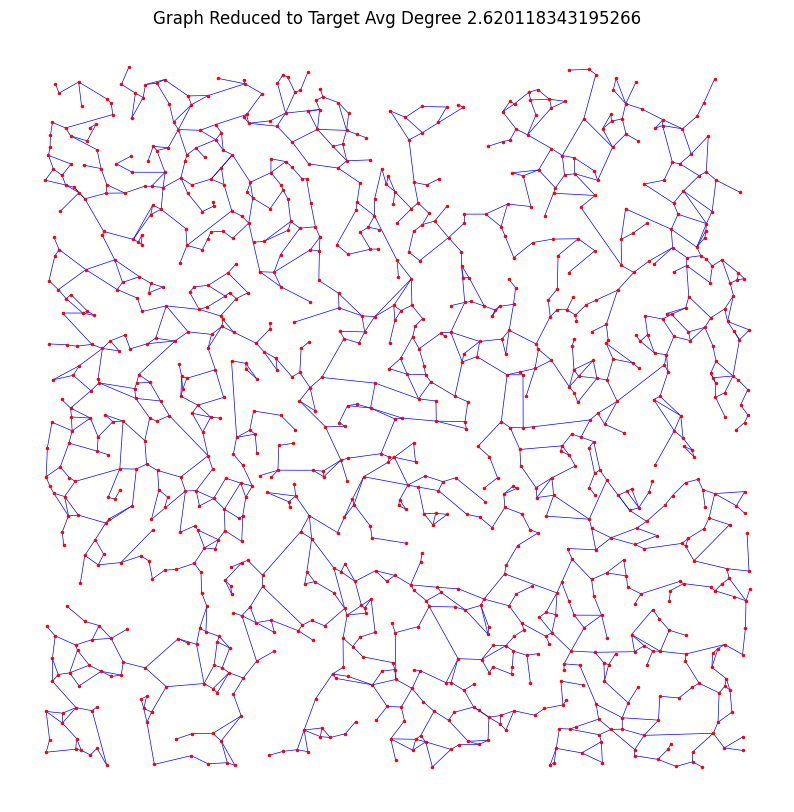

In [ ]:
def iteratively_reduce_degree(adj_matrix, target_avg_degree, min_component_size=10):
    G = nx.from_numpy_array(adj_matrix)

    while True:
        # Remove small connected components
        components = list(nx.connected_components(G))
        for component in components:
            if len(component) < min_component_size:
                G.remove_nodes_from(component)

        degrees = dict(G.degree())
        avg_degree = np.mean(list(degrees.values()))

        if avg_degree <= target_avg_degree:
            break

        # Find the node with the highest degree
        max_degree_node = max(degrees, key=degrees.get)
        G.remove_node(max_degree_node)

        # Remove nodes with degree 0 (standalone nodes)
        nodes_to_remove = [node for node, degree in G.degree() if degree == 0]
        G.remove_nodes_from(nodes_to_remove)

    new_adj_matrix = nx.to_numpy_array(G)
    return G, new_adj_matrix


G_reduced, adj_reduced = iteratively_reduce_degree(adj, average_degree_original)

# Degree distribution
degrees_reduced = dict(G_reduced.degree())
unique_degrees_reduced, counts_reduced = np.unique(list(degrees_reduced.values()), return_counts=True)
degree_distribution_reduced = dict(zip(unique_degrees_reduced, counts_reduced / sum(counts_reduced)))

print("In Reduced Graph the distribution is:")
for k in sorted(degree_distribution_reduced.keys()):
    ratio = round(degree_distribution_reduced[k], 3)
    print(f"- {k}: {ratio}")

# Mean number of nodes and edges
mean_num_nodes_reduced = G_reduced.number_of_nodes()
mean_num_edges_reduced = G_reduced.number_of_edges()
print(f"Mean number of nodes in Reduced Graph: {mean_num_nodes_reduced}")
print(f"Mean number of edges in Reduced Graph: {mean_num_edges_reduced}")

# Average closeness centrality
closeness_centrality_reduced = nx.closeness_centrality(G_reduced)
avg_closeness_centrality_reduced = np.mean(list(closeness_centrality_reduced.values()))
print(f"Average closeness centrality in Reduced Graph: {avg_closeness_centrality_reduced}")

# Plot the reduced original_graph
plt.figure(figsize=(10, 10))

positions = {i: (node.position[0], node.position[1]) for i, node in enumerate(val_n)}
filtered_nodes = list(G_reduced.nodes)
filtered_edges = list(G_reduced.edges)

for s, e in filtered_edges:
    if s in positions and e in positions:
        x1, y1 = positions[s]
        x2, y2 = positions[e]
        plt.plot([x1, x2], [y1, y2], 'b-', linewidth=.5, zorder=2)

for node in filtered_nodes:
    if node in positions:
        x, y = positions[node]
        plt.plot(x, y, 'ro', markersize=1.5, zorder=2)

plt.axis('off')
plt.title(f'Graph Reduced to Target Avg Degree {average_degree_original}')
plt.show()

In **Original Graph** the distribution is:
- 1: 0.067
- 2: 0.301
- 3: 0.581
- 4: 0.046
- 5: 0.005

Mean number of nodes in Original Graph: 845

Mean number of edges in Original Graph: 1107

Average closeness centrality in Original Graph: 0.03975

#### Run multiple times in a row

In [ ]:
def preprocess_graph(adj_matrix, min_component_size=5):
    G = nx.from_numpy_array(adj_matrix)

    # Remove small connected components
    components = list(nx.connected_components(G))
    for component in components:
        if len(component) < min_component_size:
            G.remove_nodes_from(component)

    new_adj_matrix = nx.to_numpy_array(G)
    return G, new_adj_matrix

def iteratively_reduce_degree(adj_matrix, target_avg_degree):
    G = nx.from_numpy_array(adj_matrix)

    while True:
        degrees = dict(G.degree())
        avg_degree = np.mean(list(degrees.values()))

        if avg_degree <= target_avg_degree:
            break

        # Find the node with the highest degree
        max_degree_node = max(degrees, key=degrees.get)
        G.remove_node(max_degree_node)

        # Remove nodes with degree 0 (standalone nodes)
        nodes_to_remove = [node for node, degree in G.degree() if degree == 0]
        G.remove_nodes_from(nodes_to_remove)

    new_adj_matrix = nx.to_numpy_array(G)
    return G, new_adj_matrix

def run_multiple_times(num_runs=10):
    all_graph_stats = []

    for _ in range(num_runs):
        _, _, val_n, val_e, adj = plot_network([], [], True, regen=True, regen_factor=1)
        adj, _ = preprocess_graph(adj)
        G_reduced, adj_reduced = iteratively_reduce_degree(adj, average_degree_original)
        graph_stats = calculate_statistics(G_reduced)
        all_graph_stats.append(graph_stats)

    final_avg_stats = calculate_average_stats(all_graph_stats)
    print_average_statistics(final_avg_stats)

run_multiple_times()


generate_network time taken: 0.316269 seconds
Total nodes during generating: 936, edges: 1947, aborted: 637, merged: 164

plot_network time taken: 0.321325 seconds

generate_network time taken: 1.117191 seconds
Total nodes during generating: 3233, edges: 6716, aborted: 2168, merged: 524

plot_network time taken: 1.132506 seconds

generate_network time taken: 0.916227 seconds
Total nodes during generating: 3013, edges: 6262, aborted: 1972, merged: 515

plot_network time taken: 0.927343 seconds

generate_network time taken: 1.101856 seconds
Total nodes during generating: 3277, edges: 6768, aborted: 2182, merged: 510

plot_network time taken: 1.116485 seconds

generate_network time taken: 1.033854 seconds
Total nodes during generating: 3266, edges: 6710, aborted: 2117, merged: 470

plot_network time taken: 1.049277 seconds

generate_network time taken: 0.725854 seconds
Total nodes during generating: 2314, edges: 4773, aborted: 1591, merged: 343

plot_network time taken: 0.737273 seconds


### Filter Graph with some certain degrees (OLD)

In Filtered Graph the distribution is:
- 1: 0.13
- 2: 0.324
- 3: 0.39
- 4: 0.13
- 5: 0.028
Mean number of nodes in Filtered Graph: 1119
Mean number of edges in Filtered Graph: 1456
Average closeness centrality in Filtered Graph: 0.03608533882600156


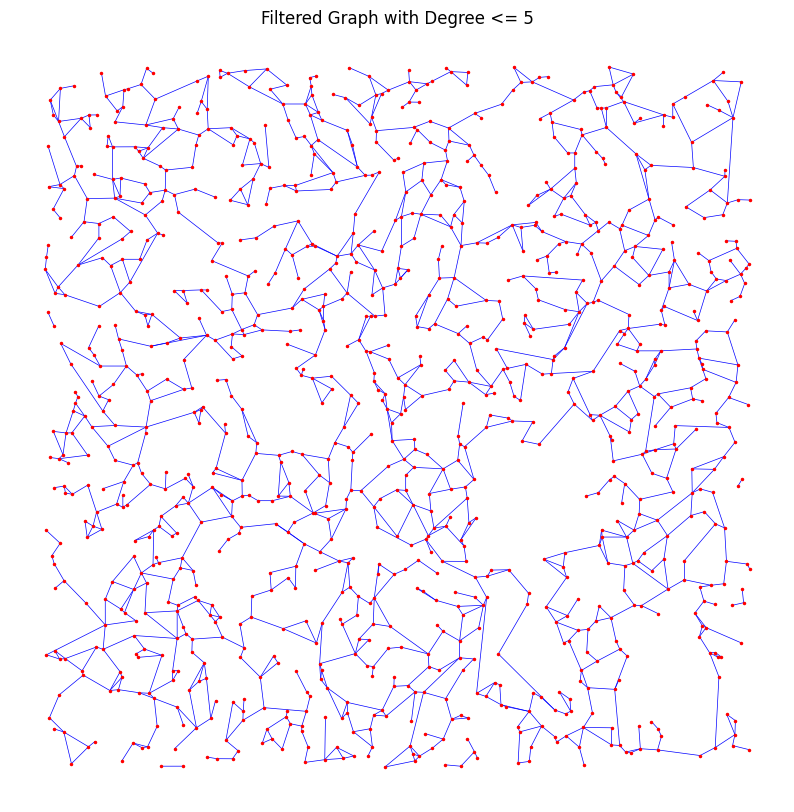

In [ ]:
def filter_graph(adj_matrix, max_degree=5):
    G = nx.from_numpy_array(adj_matrix)
    nodes_to_remove = [node for node, degree in dict(G.degree()).items() if degree > max_degree or degree == 0]
    G.remove_nodes_from(nodes_to_remove)
    new_adj_matrix = nx.to_numpy_array(G)
    return G, new_adj_matrix

# Remove nodes with degree greater than 5 and standalone nodes
G_filtered, adj_filtered = filter_graph(adj)

# Calculate degree distribution for the filtered original_graph
degrees_filtered = dict(G_filtered.degree())
unique_degrees_filtered, counts_filtered = np.unique(list(degrees_filtered.values()), return_counts=True)
degree_distribution_filtered = dict(zip(unique_degrees_filtered, counts_filtered / sum(counts_filtered)))

print("In Filtered Graph the distribution is:")
for k in sorted(degree_distribution_filtered.keys()):
    ratio = round(degree_distribution_filtered[k], 3)
    print(f"- {k}: {ratio}")

# Calculate the mean number of nodes and edges in the filtered original_graph
mean_num_nodes_filtered = G_filtered.number_of_nodes()
mean_num_edges_filtered = G_filtered.number_of_edges()
print(f"Mean number of nodes in Filtered Graph: {mean_num_nodes_filtered}")
print(f"Mean number of edges in Filtered Graph: {mean_num_edges_filtered}")

# Calculate average closeness centrality for the filtered original_graph
closeness_centrality_filtered = nx.closeness_centrality(G_filtered)
avg_closeness_centrality_filtered = np.mean(list(closeness_centrality_filtered.values()))
print(f"Average closeness centrality in Filtered Graph: {avg_closeness_centrality_filtered}")

plt.figure(figsize=(10, 10))

positions = {i: (node.position[0], node.position[1]) for i, node in enumerate(val_n)}
filtered_nodes = list(G_filtered.nodes)
filtered_edges = list(G_filtered.edges)

for s, e in filtered_edges:
    if s in positions and e in positions:
        x1, y1 = positions[s]
        x2, y2 = positions[e]
        plt.plot([x1, x2], [y1, y2], 'b-', linewidth=0.5, zorder=2)

for node in filtered_nodes:
    if node in positions:
        x, y = positions[node]
        plt.plot(x, y, 'ro', markersize=1.5, zorder=2)

plt.axis('off')
plt.title('Filtered Graph with Degree <= 5')
plt.show()